# Radiation Model Research

**Testing Linear No-Threshold Model for Radiation Level using Machine Learning and Neural Network**

*What is Linear No-Threshold (LNT) model*

Linear No Threshold model is the globaly accepted model to determine propotional harm caused by radiation to a individual. As stated in the name itself the model sets no threshold for safe radiation exposer, i.e radiation no matter how small is harmful. This was formulated after the Life Span Study (LSS) of the atomic bomb survivors in Hiroshima and Nagasaki. The lack of a threshold is due to the belief that any dose of ionizing radiation, no matter how small, carries a risk of cancer. This led to ALARA (As Low As Reasonably Achievable) as our aim with radiation exposure.

*Life Span Study (LSS)* 

After the atomic bomb explosion in Japan, LSS was started to study the affeces radiation had on survivors. This study later became the basis of our nuclear safety standard as it is the backbone behind LNT. Using LSS as a basis for radiation exposer comes with its probelms, dose-rate being the biggest one. Nuclear explosion is a acute exposer event (high exposer in short period of time) using this data to extrapolate risk for chronic exposer (low exposer over extended period of time) is biologically incompatable. But this was and remains the gold standard for radiation study due to its massive statistical number (120,000 + individuals), demographic diversity, complete dose spectrum and its long term - high quality follow up, hence LSS will also remain as the backbone for our ML model.

<h2>Code</h2>

In [1]:
import pandas as pd
import numpy as np
from numpy.linalg import lstsq
from pathlib import Path
import time
import openpyxl
import matplotlib.pyplot as plt
import matplotlib; matplotlib.use('Agg')
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy import stats, optimize
from scipy.stats import linregress, gaussian_kde
from scipy.special import gammaln
import os
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm
import json
import pickle
import warnings; warnings.filterwarnings('ignore')

Plotting LNT line

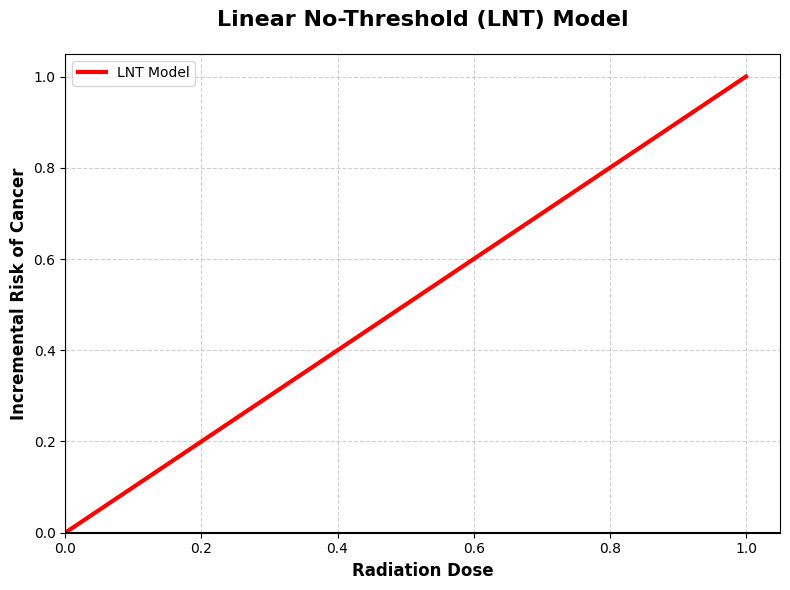

In [2]:
%matplotlib inline

def plot_simple_lnt():
    dose = np.linspace(0, 1, 100)
    
    risk = dose 
    
    # Create the plot
    plt.figure(figsize=(8, 6))
    
    # Plot the LNT line
    plt.plot(dose, risk, color='red', linewidth=3, label='LNT Model')
    
    # Formatting to match textbook LNT charts
    plt.title('Linear No-Threshold (LNT) Model', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Radiation Dose', fontsize=12, fontweight='semibold')
    plt.ylabel('Incremental Risk of Cancer', fontsize=12, fontweight='semibold')
    
    # Force axes to start exactly at the origin (0,0)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    
    # Add a bold baseline at x=0 and y=0
    plt.axvline(0, color='black', linewidth=1.5)
    plt.axhline(0, color='black', linewidth=1.5)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig('all charts/lnt_model.png')
    plt.show()
    
plot_simple_lnt()

*<h2>Analyzing LSS data</h2>*

Load Data

In [3]:
df = pd.read_csv('Data/lss14.csv')

ERR check for Data validity

In [4]:
%matplotlib inline

    # 1. Data Preparation "colon10" is taken as the dose variable and is converted from mGy to Sv.
df['dose_sv'] = df['colon10'] / 1000.0

    # We filter out rows with 0 person-years (pyr) to avoid division errors
df_clean = df[df['pyr'] > 0].copy()

    # 3. Define the Poisson Regression Model
    # The model predicts 'solid' cancer deaths based on dose,
    # while controlling for background factors (Sex, Age, City).
    # The 'offset' is log(pyr) because we are modeling Rate = Deaths / PYR.
    # Formula: log(Rate) = Intercept + Beta * Dose + Beta_Sex * Sex ...
    
formula = "solid ~ dose_sv + C(sex) + C(agecat) + C(city)"
    
model = smf.glm(
        formula=formula, 
        data=df_clean, 
        offset=np.log(df_clean['pyr']), 
        family=sm.families.Poisson()
    )

    # 4. Run the Calculations
result = model.fit()

    # 5. Extract the Risk Coefficient (Beta)
    # The coefficient 'beta' represents the slope of the log-risk.
beta = result.params['dose_sv']
    
    # Calculate ERR at 1 Sv
    # Since the model is log-linear: Relative Risk (RR) = exp(beta * dose)
    # ERR = RR - 1
err_at_1sv = np.exp(beta * 1.0) - 1

    # 6. Output the Results
print("--- LSS ERR Calculation Results ---")
print(f"Regression Coefficient (Beta): {beta:.4f}")
print(f"Excess Relative Risk (ERR) at 1 Sv: {err_at_1sv:.4f} ({err_at_1sv*100:.2f}%)")
print("\nInterpretation:")
print(f"For every 1 Sv of dose, the cancer risk increases by approximately {err_at_1sv*100:.1f}%.")
print(f"This aligns with the standard '40-60%' ERR often cited for solid cancer in LSS data.")



--- LSS ERR Calculation Results ---
Regression Coefficient (Beta): 0.3513
Excess Relative Risk (ERR) at 1 Sv: 0.4209 (42.09%)

Interpretation:
For every 1 Sv of dose, the cancer risk increases by approximately 42.1%.
This aligns with the standard '40-60%' ERR often cited for solid cancer in LSS data.


Subject Age Distribution:

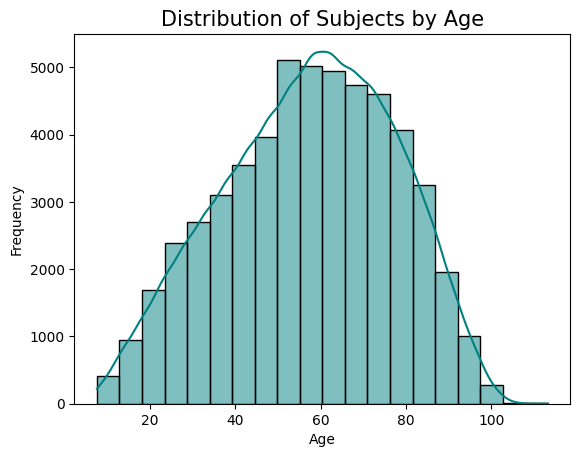

In [5]:
plt.figure()
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Subjects by Age', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('all charts/Distribution_of_Subjects_by_Age.png')
plt.show()

Quantifying Low Dose vs High Dose

--- Ratio by Person-Years (Statistical Weight) ---
Threshold (mSv) Low Dose (mSv) High Dose (mSv) Ratio (High/Low) % Data is Low Dose
------------------------------------------------------------------------------------------
20.00           2022576         1271706         0.6288               61.4%
50.00           2400342         893941          0.3724               72.9%
80.00           2530659         763623          0.3017               76.8%
100.00          2609197         685085          0.2626               79.2%


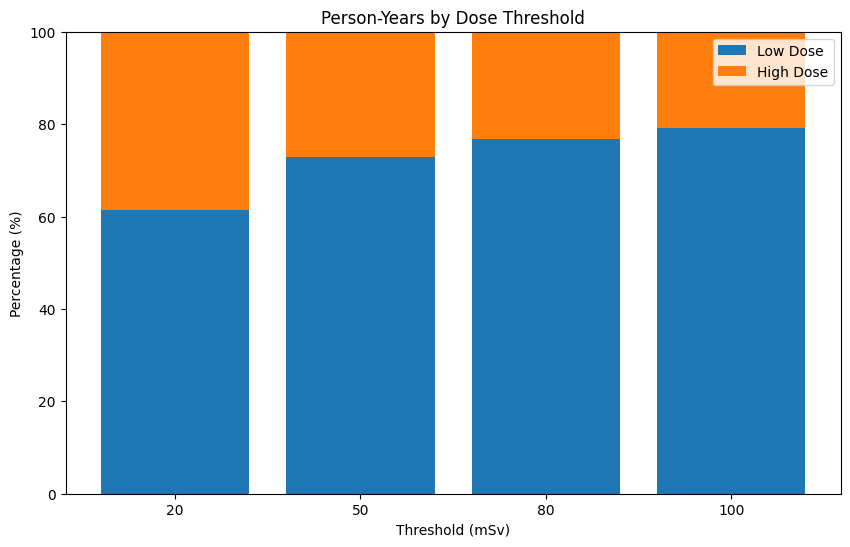

In [6]:
df['dose_gy'] = df['colon10']

# Common definitions for "Low Dose" boundaries
thresholds = [20, 50, 80, 100]

print("--- Ratio by Person-Years (Statistical Weight) ---")
print(f"{'Threshold (mSv)'} {'Low Dose (mSv)'} {'High Dose (mSv)'} {'Ratio (High/Low)'} {'% Data is Low Dose'}")
print("-" * 90)

plot_thresholds = []
plot_low = []
plot_high = []

for thresh in thresholds:
    low_mask = df['dose_gy'] <= thresh
    high_mask = df['dose_gy'] > thresh
    
    # Calculate sums
    low_pyr = df.loc[low_mask, 'pyr'].sum()
    high_pyr = df.loc[high_mask, 'pyr'].sum()
    
    # Calculate ratio
    ratio = high_pyr / low_pyr if low_pyr > 0 else 0
    percent_low = (low_pyr / (low_pyr + high_pyr)) * 100
    
    print(f"{thresh:<15.2f} {low_pyr:<15.0f} {high_pyr:<15.0f} {ratio:<20.4f} {percent_low:.1f}%")
    
    plot_thresholds.append(str(thresh))
    plot_low.append(percent_low)
    plot_high.append(100 - percent_low)

plt.figure(figsize=(10, 6))
plt.bar(plot_thresholds, plot_low, label='Low Dose')
plt.bar(plot_thresholds, plot_high, bottom=plot_low, label='High Dose')
plt.xlabel('Threshold (mSv)')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
plt.title('Person-Years by Dose Threshold')
plt.legend()
plt.savefig('all charts/person_years_chart.png', bbox_inches='tight')
plt.show()

Doescat grouped survivor vs deaths

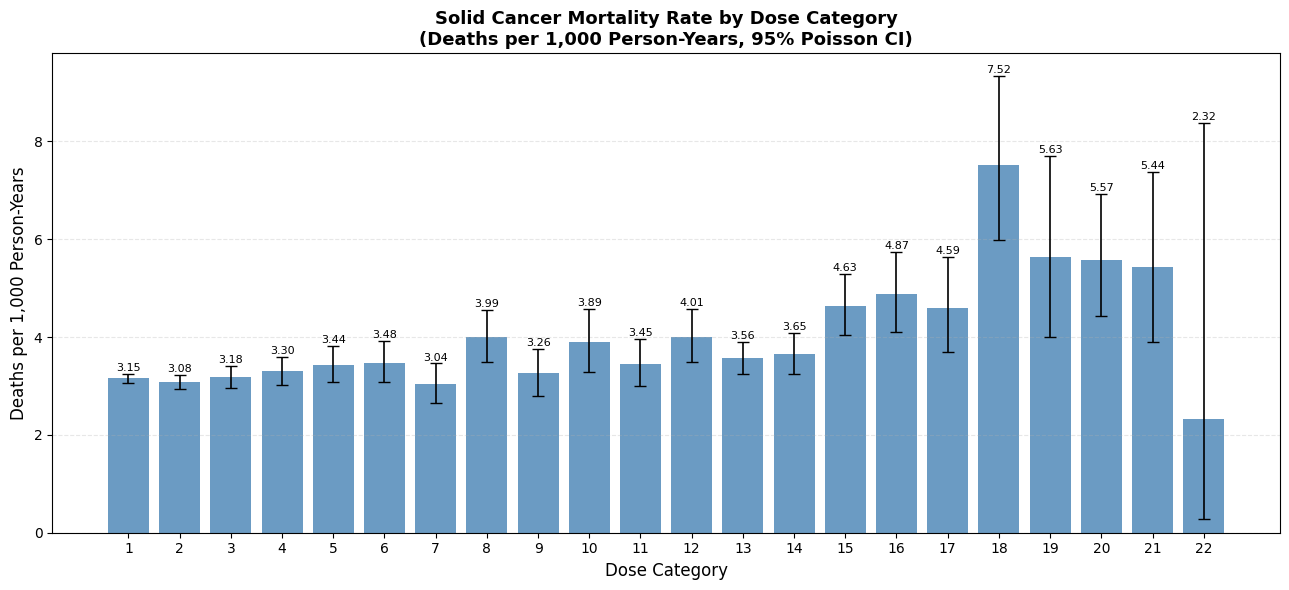

In [7]:
grouped = df.groupby('dosecat')[['solid', 'pyr']].sum().reset_index()

# Deaths per 1000 person-years — the epidemiologically correct yearly rate
grouped['rate_per_1000'] = (grouped['solid'] / grouped['pyr']) * 1000

def poisson_ci(deaths, pyr, scale=1000):
    lo = stats.chi2.ppf(0.025, 2 * deaths) / 2 if deaths > 0 else 0.0
    hi = stats.chi2.ppf(0.975, 2 * (deaths + 1)) / 2
    return (lo / pyr) * scale, (hi / pyr) * scale

grouped['ci_lo'], grouped['ci_hi'] = zip(*grouped.apply(
    lambda r: poisson_ci(r['solid'], r['pyr']), axis=1
))
grouped['err_lo'] = grouped['rate_per_1000'] - grouped['ci_lo']
grouped['err_hi'] = grouped['ci_hi'] - grouped['rate_per_1000']

fig, ax = plt.subplots(figsize=(13, 6))

x     = grouped['dosecat'].values
rates = grouped['rate_per_1000'].values
yerr  = np.array([grouped['err_lo'].values, grouped['err_hi'].values])

bars = ax.bar(x, rates, color='steelblue', alpha=0.8,
              yerr=yerr, capsize=4, error_kw={'linewidth': 1.2, 'color': 'black'})

# Rate label above each bar
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + yerr[1][list(rates).index(rate)] + 0.02,
            f'{rate:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title("Solid Cancer Mortality Rate by Dose Category\n"
             "(Deaths per 1,000 Person-Years, 95% Poisson CI)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Dose Category", fontsize=12)
ax.set_ylabel("Deaths per 1,000 Person-Years", fontsize=12)
ax.set_xticks(x)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("all charts/mortality_rate_by_dosecat.png", dpi=150, bbox_inches='tight')
plt.show(fig)


Mortality by Age

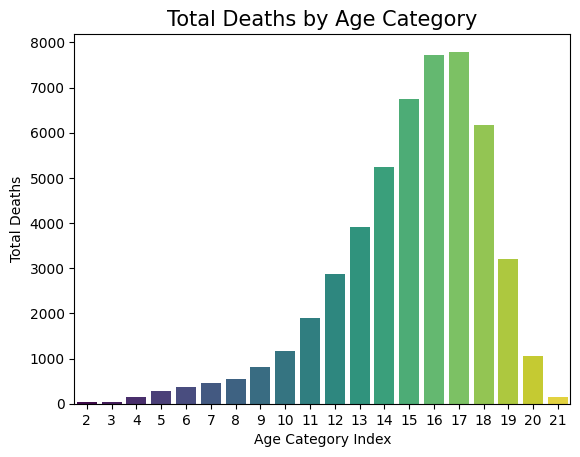

In [8]:
plt.figure()
age_death = df.groupby('agecat')['death'].sum().reset_index()

# Fix: Assign 'agecat' to hue and set legend=False
sns.barplot(
    data=age_death, 
    x='agecat', 
    y='death', 
    hue='agecat', 
    palette='viridis', 
    legend=False
)

plt.title('Total Deaths by Age Category', fontsize=15)
plt.xlabel('Age Category Index')
plt.ylabel('Total Deaths')
plt.savefig('all charts/total_deaths_by_agecat.png', bbox_inches='tight')
plt.show()

Age vs Solid Deaths

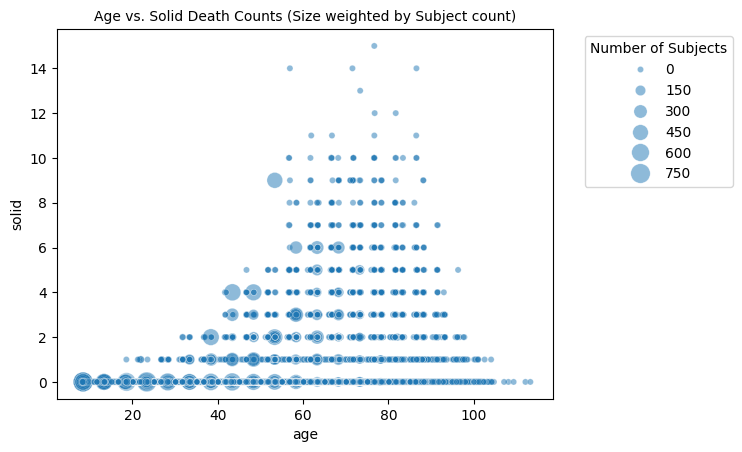

In [11]:
plt.figure()
sns.scatterplot(data=df, x='age', y='solid', alpha=0.5, size='subjects', sizes=(20, 200))
plt.title('Age vs. Solid Death Counts (Size weighted by Subject count)', fontsize=10)
plt.legend(title='Number of Subjects', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('all charts/age_vs_solid_deaths.png', bbox_inches='tight')
plt.show()

Mortality Rate by Dose Category


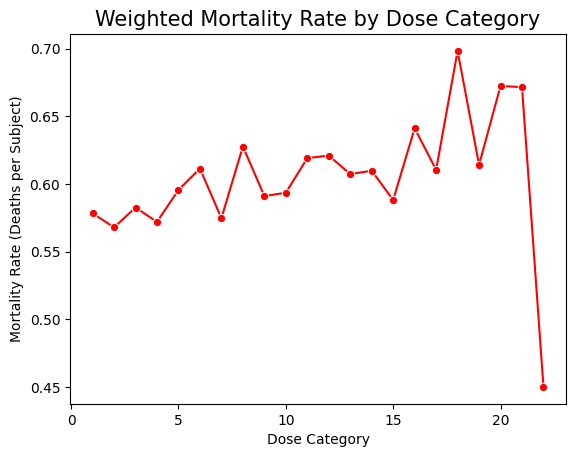

In [10]:
plt.figure()
# Calculate weighted mortality rate (Total deaths / Total subjects) for each dose category
dose_stats = df.groupby('dosecat').agg({'death': 'sum', 'subjects': 'sum'}).reset_index()
dose_stats['mortality_rate'] = dose_stats['death'] / dose_stats['subjects']

sns.lineplot(data=dose_stats, x='dosecat', y='mortality_rate', marker='o', color='red')
plt.title('Weighted Mortality Rate by Dose Category', fontsize=15)
plt.xlabel('Dose Category')
plt.ylabel('Mortality Rate (Deaths per Subject)')
plt.savefig('all charts/weighted_mortality_rate.png', bbox_inches='tight')
plt.show()

Cancer Type

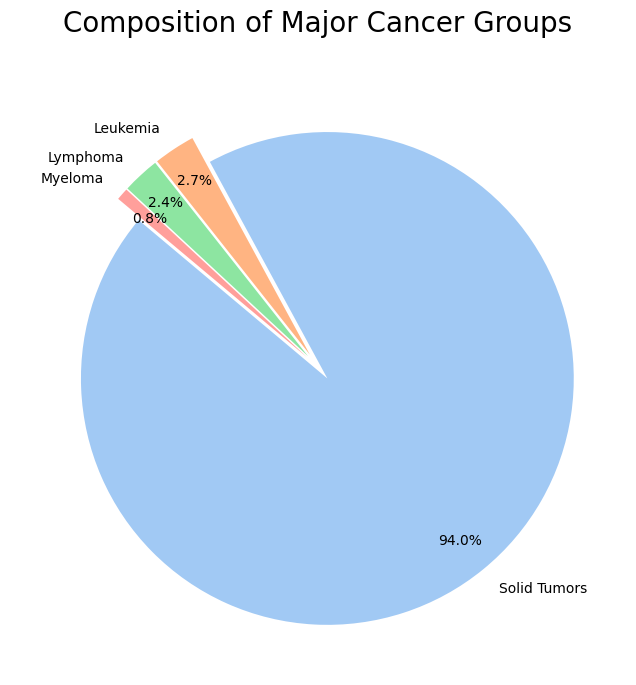

In [12]:
plt.figure(figsize=(11, 8))

cancer_types = {
    'Solid Tumors': df['solid'].sum(),
    'Leukemia': df['leukemia'].sum(),
    'Lymphoma': df['lymphoma'].sum(),
    'Myeloma': df['myeloma'].sum()
}

# Create an explode tuple (e.g., 0.05 for every slice to separate them slightly)
explode = (0.06, 0.06, 0.06, 0.06) 

plt.pie(
    cancer_types.values(), 
    labels=cancer_types.keys(), 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=140,
    explode=explode,    # Separates the slices
    pctdistance=0.85,    # Moves the % numbers further from the center
    labeldistance=1.1   # Moves the category labels slightly further out
)

plt.title('Composition of Major Cancer Groups', fontsize=20, pad=20)
plt.savefig('all charts/cancer_composition.png', bbox_inches='tight')
plt.show()

Where our data mostly sits

C:\Users\nirau\AppData\Local\Temp\ipykernel_15076\2572768953.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dose_counts, x='dosecat', y='subjects', palette='viridis')


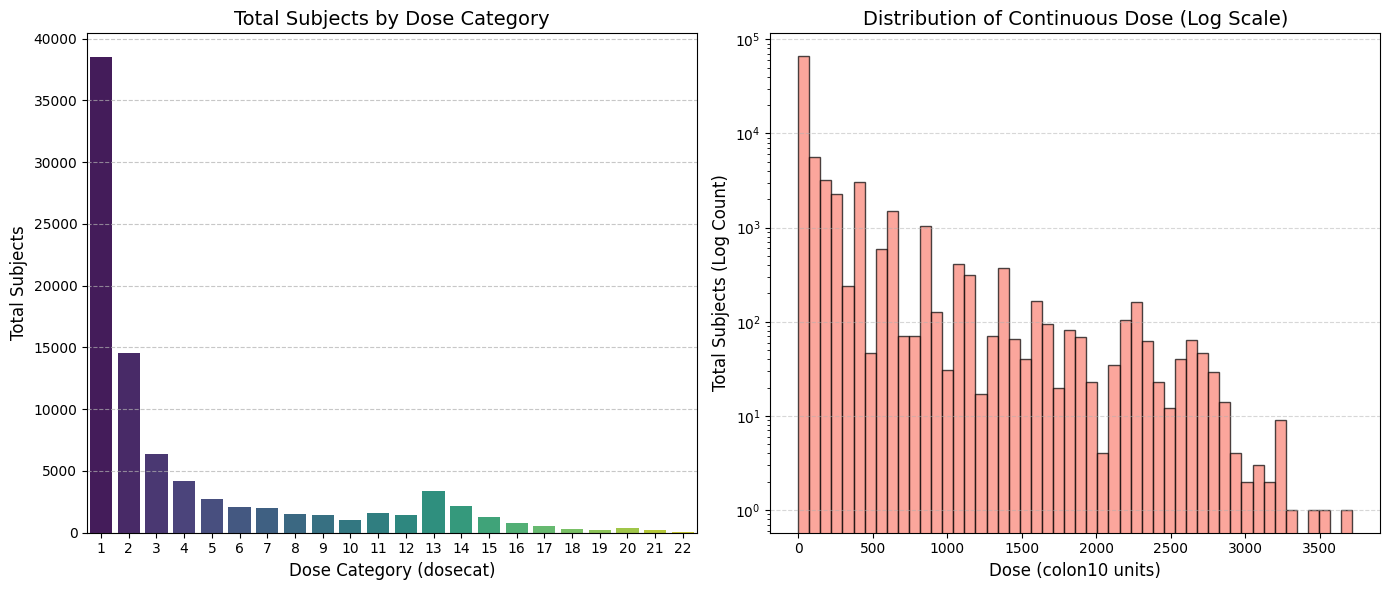

Total Subjects: 86,611
Subjects in 'Low Dose' categories (1-5): 66,388 (76.7%)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('Data/lss14.csv')

# 2. Setup the figure
plt.figure(figsize=(14, 6))

# Subplot 1: Distribution by Dose Category (dosecat)
# We sum the 'subjects' for each category to get the true population count
plt.subplot(1, 2, 1)
dose_counts = df.groupby('dosecat')['subjects'].sum().reset_index()
sns.barplot(data=dose_counts, x='dosecat', y='subjects', palette='viridis')
plt.title('Total Subjects by Dose Category', fontsize=14)
plt.xlabel('Dose Category (dosecat)', fontsize=12)
plt.ylabel('Total Subjects', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Continuous Dose Distribution (Weighted by Subjects)
# Using 'colon10' as the representative continuous dose
plt.subplot(1, 2, 2)
# Filter out potential placeholder values like -99 if they exist
plot_data = df[df['colon10'] >= 0] 

plt.hist(plot_data['colon10'], bins=50, weights=plot_data['subjects'], 
         color='salmon', edgecolor='black', alpha=0.7)
plt.yscale('log') # Log scale is often better because low doses dominate so heavily
plt.title('Distribution of Continuous Dose (Log Scale)', fontsize=14)
plt.xlabel('Dose (colon10 units)', fontsize=12)
plt.ylabel('Total Subjects (Log Count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Summary statistics for context
total_subjects = df['subjects'].sum()
low_dose_subjects = df[df['dosecat'] <= 5]['subjects'].sum()
print(f"Total Subjects: {total_subjects:,.0f}")
print(f"Subjects in 'Low Dose' categories (1-5): {low_dose_subjects:,.0f} ({(low_dose_subjects/total_subjects)*100:.1f}%)")

NGAM Model - Gemini Version (almost no chnage in actual output)

In [13]:
"""
=============================================================================
LSS14 NEURAL GAM — ATTRIBUTABLE FRACTION & DOSE LIMIT ANALYSIS
=============================================================================


1. DOSE SUBNET: linear skip connection  [fixes flat/negative AF at low dose]
   v4: f_dose(x) = subnet(x)   — starts near-zero everywhere
   v5: f_dose(x) = skip * x + subnet(x)
       skip weight initialised to GLM slope (0.261 in std units)
       subnet weights zeroed at init
   Effect: f_dose starts exactly at the GLM linear solution and learns
   residual non-linearity on top of it. The AF curve can no longer
   start negative because the initial slope is correct.

2. LNT NULL: beta_dose initialised to GLM slope  [fixes negative LRT]
   v4: beta_dose = 0.0 at init  — starts far from solution
   v5: beta_dose = 0.261 (GLM value in standardised units) at init
   Effect: both models start from the same sensible initial condition,
   so the LRT comparison is fair from the first epoch.

3. MONOTONICITY PENALTY: applied from dose_std_min (not 30th pct)
   v4: penalty only above 6.9 mGy — model was free to dip below 0 AF
   v5: penalty across the full dose range
   Effect: prevents the negative AF dip at low doses entirely.

4. LRT: computed on validation set only  [fixes negative LRT statistic]
   v4: LRT on full_loader — training set memorisation bias
   v5: LRT on val_loader  — fair generalisation test
   Both models trained on same train_idx, evaluated on same val_idx.
   This answers: does NeuralGAM generalise better than LNT on unseen data?

5. PATIENCE increased 80 -> 120, LR reduced 1e-3 -> 5e-4 after warmup
   v4 stopped at epoch 90/171 which may be premature convergence.

ARCHITECTURE (unchanged from v4 except DoseSubNet)
---------------------------------------------------
  f_dose:  DoseSubNet(skip + 1->16->8->1)
  f_age:   SubNet(1->32->16->1)
  f_agex:  SubNet(1->16->8->1)
  f_ctime: SubNet(1->16->8->1)
  Linear:  sex, city, sex_x_agex
  Total:   ~1,146 params
"""

# =============================================================================
# CONFIG
# =============================================================================
SEED        = 42
DATA_PATH   = 'Data/lss14.csv'
OUT_DIR     = '.'
MODEL_PATH  = os.path.join(OUT_DIR, 'trained model/ngam_v5_best_gemini.pt')
LNT_PATH    = os.path.join(OUT_DIR, 'trained model/ngam_v5_lnt_best_gemini.pt')
PARAMS_PATH = os.path.join(OUT_DIR, 'trained model/ngam_v5_params_gemini.json')

EPOCHS      = 1000
PATIENCE    = 120
LR          = 5e-4
LR_WARMUP   = 30
WEIGHT_DECAY= 1e-4
BATCH_SIZE  = 512
N_MC        = 500
N_DOSE_GRID = 2000
N_SCAN_BINS = 15
N_LRT_SCAN  = 100
MONO_LAMBDA = 0.05
AF_CEILINGS = [0.01, 0.05, 0.10]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED); np.random.seed(SEED)
print("="*72)
print("LSS14 NEURAL GAM v5 — ATTRIBUTABLE FRACTION & DOSE LIMIT")
print("="*72)

# =============================================================================
# 1.  DATA
# =============================================================================
print("\n[1] Loading & preprocessing...")
df_raw = pd.read_csv(DATA_PATH)
df_raw.replace(-99.0, np.nan, inplace=True)
df_raw['dose_mgy']   = df_raw['colon10'] / 10.0
df_raw['sex_x_agex'] = (df_raw['sex'] - 1) * df_raw['agex']

features = ['sex','agex','age','city','ctime','dose_mgy','sex_x_agex']
target, exposure = 'solid', 'pyr'
df = df_raw[features + [target, exposure]].dropna().copy()

print(f"    Rows: {df.shape[0]:,}  Solid: {df[target].sum():,.0f}  PY: {df[exposure].sum():,.0f}")
print(f"    Dose: {df['dose_mgy'].min():.3f} – {df['dose_mgy'].max():.1f} mGy")

dc1 = df[df['dose_mgy'] < 1.0]
bg_rate_raw = dc1[target].sum() / dc1[exposure].sum() * 10000
print(f"    Background rate (dose<1 mGy): {bg_rate_raw:.3f} per 10,000 PY")

n_total  = len(df)
n_train  = int(0.8 * n_total)
n_val    = n_total - n_train
rng      = torch.Generator().manual_seed(SEED)
all_idx  = torch.randperm(n_total, generator=rng).tolist()
train_idx = all_idx[:n_train]; val_idx = all_idx[n_train:]

X_raw   = df[features].values.astype(np.float32)
y_raw   = df[target].values.astype(np.float32)
pyr_raw = df[exposure].values.astype(np.float32)
X_raw[:, 0] -= 1.0   # sex  1/2 -> 0/1
X_raw[:, 3] -= 1.0   # city 1/2 -> 0/1
FI = {name: i for i, name in enumerate(features)}

params_std = {'features': features}
def standardise(arr, col, name, train_indices):
    mu = float(arr[train_indices, col].mean())
    sigma = float(arr[train_indices, col].std()) + 1e-8
    arr[:, col] = (arr[:, col] - mu) / sigma
    params_std[f'{name}_mean'] = mu; params_std[f'{name}_std'] = sigma

for col, name in [(1,'agex'),(2,'age'),(4,'ctime'),(5,'dose_mgy'),(6,'sex_x_agex')]:
    standardise(X_raw, col, name, train_idx)

X_t     = torch.tensor(X_raw,   dtype=torch.float32).to(device)
y_t     = torch.tensor(y_raw,   dtype=torch.float32).view(-1,1).to(device)
pyr_t   = torch.tensor(pyr_raw, dtype=torch.float32).view(-1,1).to(device)
log_pyr_t = torch.log(pyr_t + 1e-8)

full_ds  = TensorDataset(X_t, y_t, log_pyr_t)
train_ds = torch.utils.data.Subset(full_ds, train_idx)
val_ds   = torch.utils.data.Subset(full_ds, val_idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader   = DataLoader(val_ds,   batch_size=1024, shuffle=False)
full_loader  = DataLoader(full_ds,  batch_size=2048, shuffle=False)

print(f"    Train: {n_train:,}  Val: {n_val:,}")
dose_mgy_all = df['dose_mgy'].values
age_all = df['age'].values; agex_all = df['agex'].values; ctime_all = df['ctime'].values

# Min dose in std units — for monotonicity applied across full dose range
dose_std_min = float(X_t[:, FI['dose_mgy']].min())
dose_std_max = float(X_t[:, FI['dose_mgy']].max())

# =============================================================================
# 2.  GLM REFERENCE  (IRLS — used for initialisation and validation)
# =============================================================================
print("\n[2] Fitting Poisson GLM reference (IRLS)...")
df_train = df.iloc[train_idx]
X_glm = np.column_stack([np.ones(len(df_train)), df_train['dose_mgy'].values, df_train['age'].values,
                          df_train['sex'].values-1, df_train['agex'].values, df_train['ctime'].values,
                          df_train['city'].values-1, df_train['sex_x_agex'].values])
y_glm = df_train[target].values.astype(float)
pyr_glm = df_train[exposure].values.astype(float)
log_off = np.log(pyr_glm + 1e-10)
beta_glm = np.zeros(X_glm.shape[1])
for _ in range(200):
    mu_glm = np.exp(log_off + X_glm @ beta_glm)
    z = (log_off + X_glm @ beta_glm) - log_off + (y_glm - mu_glm)/(mu_glm + 1e-10)
    Xw = X_glm * np.sqrt(mu_glm[:, None]); zw = z * np.sqrt(mu_glm)
    beta_new, _, _, _ = lstsq(Xw, zw, rcond=None)
    if np.max(np.abs(beta_new - beta_glm)) < 1e-10: break
    beta_glm = beta_new

b_dose_glm     = beta_glm[1]
b_dose_glm_std = b_dose_glm * params_std['dose_mgy_std']   # in standardised units
print(f"    GLM b_dose: {b_dose_glm:.6f}/mGy  ({b_dose_glm_std:.6f} in std units)")
print(f"    GLM ERR/Gy: {float(np.exp(b_dose_glm*1000)-1):.3f}")

median_x_glm = np.median(X_glm, axis=0).copy(); median_x_glm[1] = 0.0
dose_ax_glm  = np.linspace(0, df['dose_mgy'].max(), N_DOSE_GRID)
X_grid_glm   = np.tile(median_x_glm, (N_DOSE_GRID, 1)); X_grid_glm[:, 1] = dose_ax_glm
rates_glm    = np.exp(X_grid_glm @ beta_glm) * 10000
bg_glm       = rates_glm[0]
af_glm       = (rates_glm - bg_glm) / (rates_glm + 1e-12) * 100
print(f"    GLM background (median cov, dose=0): {bg_glm:.2f}/10,000 PY")

# =============================================================================
# 3.  ARCHITECTURE
# =============================================================================

class SubNet(nn.Module):
    """Standard single-feature subnet. 1->h1->h2->1, Softplus, Dropout ON for MC."""
    def __init__(self, h1=16, h2=8, dropout_p=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, h1), nn.Softplus(), nn.Dropout(dropout_p),
            nn.Linear(h1, h2), nn.Softplus(), nn.Dropout(dropout_p),
            nn.Linear(h2, 1))
    def forward(self, x): return self.net(x)


class DoseSubNet(nn.Module):
    """
    Dose subnet with linear skip connection.

    f_dose(x) = skip_weight * x  +  nonlinear_subnet(x)

    The skip_weight is initialised to the GLM slope (b_dose_glm_std) so the
    model starts exactly at the correct linear solution.  The nonlinear subnet
    is zeroed at init so it contributes nothing initially and learns only the
    residual non-linearity on top of the linear term.

    This solves two problems:
      - AF curve starting negative (wrong initial slope)
      - NeuralGAM converging to worse solution than LNT (bad starting point)

    Dropout on the nonlinear path for MC Dropout uncertainty estimation.
    The skip connection is deterministic (no dropout) — it represents the
    known linear component which should not be uncertain.
    """
    def __init__(self, h1=16, h2=8, dropout_p=0.15, init_slope=0.0):
        super().__init__()
        self.skip = nn.Parameter(torch.tensor([[init_slope]], dtype=torch.float32))
        self.net  = nn.Sequential(
            nn.Linear(1, h1), nn.Softplus(), nn.Dropout(dropout_p),
            nn.Linear(h1, h2), nn.Softplus(), nn.Dropout(dropout_p),
            nn.Linear(h2, 1))
        # Zero the nonlinear subnet at init so it starts as pure linear
        with torch.no_grad():
            # Zero ONLY the final output layer weights to avoid breaking symmetry in hidden layers
            nn.init.zeros_(self.net[6].weight)
            nn.init.zeros_(self.net[6].bias)

    def forward(self, x):
        return self.skip * x + self.net(x)


class NeuralGAM(nn.Module):
    """
    log(rate) = bias + beta_sex*sex + beta_city*city + beta_sxa*sxa
              + f_agex(agex) + f_age(age) + f_ctime(ctime)
              + f_dose(dose)           <- DoseSubNet with skip
    mu = exp(log_rate + log_pyr)
    """
    def __init__(self, dose_init_slope=0.0):
        super().__init__()
        self.bias      = nn.Parameter(torch.zeros(1))
        self.beta_sex  = nn.Parameter(torch.zeros(1))
        self.beta_city = nn.Parameter(torch.zeros(1))
        self.beta_sxa  = nn.Parameter(torch.zeros(1))
        self.f_agex    = SubNet(16,  8,  0.10)
        self.f_age     = SubNet(32,  16, 0.10)
        self.f_ctime   = SubNet(16,  8,  0.10)
        self.f_dose    = DoseSubNet(16, 8, 0.15, init_slope=dose_init_slope)

    def log_rate(self, x):
        return (self.bias
                + self.beta_sex  * x[:, FI['sex']        :FI['sex']        +1]
                + self.beta_city * x[:, FI['city']       :FI['city']       +1]
                + self.beta_sxa  * x[:, FI['sex_x_agex'] :FI['sex_x_agex'] +1]
                + self.f_agex   (x[:, FI['agex']         :FI['agex']       +1])
                + self.f_age    (x[:, FI['age']           :FI['age']        +1])
                + self.f_ctime  (x[:, FI['ctime']         :FI['ctime']      +1])
                + self.f_dose   (x[:, FI['dose_mgy']      :FI['dose_mgy']   +1]))

    def forward(self, x, log_pyr):
        return self.log_rate(x) + log_pyr


class LinearNTModel(nn.Module):
    """
    LNT null: beta_dose*dose replaces f_dose.
    beta_dose initialised to GLM slope in std units so it starts from the
    correct solution and the LRT comparison is fair.
    """
    def __init__(self, dose_init_slope=0.0):
        super().__init__()
        self.bias      = nn.Parameter(torch.zeros(1))
        self.beta_sex  = nn.Parameter(torch.zeros(1))
        self.beta_city = nn.Parameter(torch.zeros(1))
        self.beta_sxa  = nn.Parameter(torch.zeros(1))
        self.beta_dose = nn.Parameter(torch.tensor([[dose_init_slope]],
                                                    dtype=torch.float32))
        self.f_agex    = SubNet(16,  8,  0.10)
        self.f_age     = SubNet(32,  16, 0.10)
        self.f_ctime   = SubNet(16,  8,  0.10)

    def forward(self, x, log_pyr):
        lr = (self.bias
              + self.beta_sex  * x[:, FI['sex']        :FI['sex']        +1]
              + self.beta_city * x[:, FI['city']       :FI['city']       +1]
              + self.beta_sxa  * x[:, FI['sex_x_agex'] :FI['sex_x_agex'] +1]
              + self.beta_dose * x[:, FI['dose_mgy']   :FI['dose_mgy']   +1]
              + self.f_agex   (x[:, FI['agex']         :FI['agex']       +1])
              + self.f_age    (x[:, FI['age']           :FI['age']        +1])
              + self.f_ctime  (x[:, FI['ctime']         :FI['ctime']      +1]))
        return lr + log_pyr

# =============================================================================
# 4.  LOSS
# =============================================================================

def poisson_nll(log_mu, y):
    """Numerically stable Poisson NLL."""
    return (torch.exp(log_mu) - y * log_mu).mean()


def monotonicity_penalty(f_dose, dose_grid_std, lam):
    """
    Penalise negative df_dose/d_dose across the full dose range.
    Applied from dose_std_min (not 30th pct) to prevent AF dip at low doses.
    """
    if lam == 0.0: return torch.tensor(0.0)
    grid = dose_grid_std.view(-1, 1).detach().clone().requires_grad_(True)
    grad = torch.autograd.grad(f_dose(grid).sum(), grid, create_graph=True)[0]
    return lam * torch.relu(-grad).pow(2).mean()

# =============================================================================
# 5.  TRAINING
# =============================================================================

def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, patience=PATIENCE,
                save_path=None, label='model'):

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=15, factor=0.5, min_lr=1e-6)

    # Full dose grid for monotonicity penalty
    dose_grid = torch.linspace(dose_std_min, dose_std_max, 300).to(device)

    best_val, patience_c = float('inf'), 0
    train_h, val_h = [], []

    for epoch in range(epochs):
        # LR warmup
        if epoch < LR_WARMUP:
            for pg in optimizer.param_groups:
                pg['lr'] = LR * (epoch + 1) / LR_WARMUP

        model.train(); ep_tr = 0.0
        for bX, by, blp in train_loader:
            optimizer.zero_grad()
            log_mu = model(bX, blp)
            loss = poisson_nll(log_mu, by)
            if hasattr(model, 'f_dose'):
                loss = loss + monotonicity_penalty(
                    model.f_dose, dose_grid, MONO_LAMBDA)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            ep_tr += loss.item()

        model.eval(); ep_vl = 0.0
        with torch.no_grad():
            for bX, by, blp in val_loader:
                ep_vl += poisson_nll(model(bX, blp), by).item()

        avg_tr = ep_tr / len(train_loader)
        avg_vl = ep_vl / len(val_loader)
        train_h.append(avg_tr); val_h.append(avg_vl)
        if epoch >= LR_WARMUP: scheduler.step(avg_vl)

        if avg_vl < best_val - 1e-6:
            best_val, patience_c = avg_vl, 0
            if save_path: torch.save(model.state_dict(), save_path)
        else:
            patience_c += 1

        if (epoch + 1) % 100 == 0:
            print(f"    [{label}] ep {epoch+1:4d} | "
                  f"tr {avg_tr:.5f} | vl {avg_vl:.5f} | "
                  f"pat {patience_c}/{patience} | "
                  f"lr {optimizer.param_groups[0]['lr']:.2e}")

        if patience_c >= patience:
            print(f"    [{label}] Early stop ep {epoch+1}")
            break

    if save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, weights_only=True))
    return train_h, val_h, best_val

# =============================================================================
# 6.  TRAIN
# =============================================================================
print(f"\n[3] Training NeuralGAM v5...")
model    = NeuralGAM(dose_init_slope=b_dose_glm_std).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"    Parameters:  {n_params:,}")
print(f"    Dose skip init: {b_dose_glm_std:.6f}  (GLM slope in std units)")

train_hist, val_hist, best_val = train_model(
    model, train_loader, val_loader,
    save_path=MODEL_PATH, label='NeuralGAM')
best_ep = int(np.argmin(val_hist))
print(f"    Best epoch: {best_ep}  val loss: {best_val:.6f}")

print(f"\n[4] Training LNT null...")
lnt_model = LinearNTModel(dose_init_slope=b_dose_glm_std).to(device)
k_lnt     = sum(p.numel() for p in lnt_model.parameters() if p.requires_grad)
print(f"    beta_dose init: {b_dose_glm_std:.6f}  (GLM slope in std units)")
lnt_train_h, lnt_val_h, lnt_best = train_model(
    lnt_model, train_loader, val_loader,
    save_path=LNT_PATH, label='LNT-null')
lnt_best_ep = int(np.argmin(lnt_val_h))
print(f"    LNT best epoch: {lnt_best_ep}  val loss: {lnt_best:.6f}")

# =============================================================================
# 7.  AF CURVES  (MC Dropout over median-covariate dose sweep)
# =============================================================================
print(f"\n[5] Computing AF curves (n_mc={N_MC})...")
median_x  = X_t.median(dim=0).values.cpu().numpy().copy()
dose_mgy_ax = np.linspace(0.0, df['dose_mgy'].max(), N_DOSE_GRID)
dose_std_ax = (dose_mgy_ax - params_std['dose_mgy_mean']) / params_std['dose_mgy_std']

X_dose_grid = np.tile(median_x, (N_DOSE_GRID, 1)).astype(np.float32)
X_dose_grid[:, FI['dose_mgy']] = dose_std_ax.astype(np.float32)
X_dose_t    = torch.tensor(X_dose_grid, dtype=torch.float32).to(device)
log_pyr_zero = torch.zeros(N_DOSE_GRID, 1).to(device)   # pyr=1 -> log_pyr=0 -> gives rate

model.train()
mc_rate_curves = []
with torch.no_grad():
    for _ in range(N_MC):
        log_rate = model(X_dose_t, log_pyr_zero)
        mc_rate_curves.append(torch.exp(log_rate).cpu().numpy().flatten())
mc_rate_curves = np.array(mc_rate_curves); model.eval()

bg_mc      = mc_rate_curves[:, 0]
af_curves  = (mc_rate_curves - bg_mc[:, np.newaxis]) / (mc_rate_curves + 1e-12)
af_mean    = af_curves.mean(0)
af_p025    = np.percentile(af_curves, 2.5,  axis=0)
af_p975    = np.percentile(af_curves, 97.5, axis=0)
rate_mean  = mc_rate_curves.mean(0) * 10000
rate_p025  = np.percentile(mc_rate_curves, 2.5,  axis=0) * 10000
rate_p975  = np.percentile(mc_rate_curves, 97.5, axis=0) * 10000
bg_rate_model = float(bg_mc.mean()) * 10000

print(f"    Model background (dose=0, median cov): {bg_rate_model:.2f}/10,000 PY")
print(f"    GLM   background (dose=0, median cov): {bg_glm:.2f}/10,000 PY")

# =============================================================================
# 8.  D* CROSSINGS
# =============================================================================
print(f"\n[6] Finding D* crossings...")

def find_d_star(af_curve, dose_axis, ceiling):
    smoothed = np.convolve(af_curve, np.ones(30)/30, mode='same')
    min_idx  = np.searchsorted(dose_axis, 1.0)
    for i in range(min_idx, len(smoothed)):
        if smoothed[i] >= ceiling:
            if i == 0: return dose_axis[0]
            frac = (ceiling - smoothed[i-1]) / (smoothed[i] - smoothed[i-1] + 1e-12)
            return dose_axis[i-1] + frac * (dose_axis[i] - dose_axis[i-1])
    return np.nan

d_star_results = {}
for ceiling in AF_CEILINGS:
    d_star_mc = np.array([
        find_d_star(af_curves[i], dose_mgy_ax, ceiling) for i in range(N_MC)])
    valid = d_star_mc[~np.isnan(d_star_mc)]
    glm_ref = find_d_star(af_glm/100, dose_ax_glm, ceiling)
    if len(valid) == 0:
        d_star_results[ceiling] = {
            'median': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan,
            'n_valid': 0, 'mc_samples': np.array([]), 'glm_ref': glm_ref}
    else:
        d_star_results[ceiling] = {
            'median'    : float(np.median(valid)),
            'ci_lo'     : float(np.percentile(valid, 2.5)),
            'ci_hi'     : float(np.percentile(valid, 97.5)),
            'n_valid'   : len(valid),
            'mc_samples': valid,
            'glm_ref'   : float(glm_ref),
        }
    r = d_star_results[ceiling]
    print(f"    D*({ceiling*100:.0f}%)  GAM={r['median']:.1f} mGy "
          f"[{r['ci_lo']:.1f}, {r['ci_hi']:.1f}]  "
          f"GLM={r['glm_ref']:.1f} mGy  "
          f"(n_valid={r['n_valid']}/{N_MC})")

# =============================================================================
# 9.  FORMAL LRT  (evaluated on validation set — fair generalisation test)
# =============================================================================
print(f"\n[7] LRT on validation set...")

def val_loglik(mdl, loader):
    """
    Poisson log-likelihood on validation data only.
    Using val_loader (not full_loader) avoids training-set memorisation bias.
    Both models trained on identical train_idx, evaluated on identical val_idx.
    """
    mdl.eval(); ll = 0.0
    with torch.no_grad():
        for bX, by, blp in loader:
            log_mu = mdl(bX, blp)
            mu  = torch.exp(log_mu)
            ll += (by * log_mu - mu).sum().item()
    return ll

ll_ngam  = val_loglik(model,     val_loader)
ll_lnt_v = val_loglik(lnt_model, val_loader)
lr_stat  = 2.0 * (ll_ngam - ll_lnt_v)
p_lrt    = float(1.0 - stats.chi2.cdf(max(lr_stat, 0.0), df=1))

# BIC uses n = validation set size (consistent with val-set evaluation)
n_val_bic = n_val
bic_ngam  = -2 * ll_ngam  + n_params * np.log(n_val_bic)
bic_lnt   = -2 * ll_lnt_v + k_lnt    * np.log(n_val_bic)
delta_bic = bic_lnt - bic_ngam   # positive = NeuralGAM preferred

if   p_lrt < 0.001: lrt_verdict = "p < 0.001 — strong evidence against LNT"
elif p_lrt < 0.05:  lrt_verdict = "p < 0.05  — significant departure from LNT"
else:               lrt_verdict = "p >= 0.05 — insufficient evidence vs LNT"

print(f"    LL(NeuralGAM): {ll_ngam:.3f}")
print(f"    LL(LNT):       {ll_lnt_v:.3f}")
print(f"    LRT = {lr_stat:.3f}  chi2(1)  p = {p_lrt:.6f}")
print(f"    ΔBIC (LNT - NeuralGAM) = {delta_bic:.1f}  "
      f"({'NeuralGAM preferred' if delta_bic > 0 else 'LNT preferred'})")
print(f"    {lrt_verdict}")

# =============================================================================
# 10.  PROFILE-LL SCAN  (qcut bins — no dosecat)
# =============================================================================
print(f"\n[8] Profile-LL scan ({N_SCAN_BINS} qcut bins)...")
df['scan_bin'] = pd.qcut(df['dose_mgy'], q=N_SCAN_BINS, duplicates='drop')
scan_agg = (df.groupby('scan_bin', observed=True)
              .agg(dose_mgy=('dose_mgy','mean'),
                   solid=('solid','sum'), pyr=('pyr','sum'))
              .dropna().reset_index().sort_values('dose_mgy'))
d_agg = scan_agg['dose_mgy'].values
c_agg = scan_agg['solid'].values
p_agg = scan_agg['pyr'].values
x0    = [np.log(c_agg.sum()/p_agg.sum()), 0.003]
opts  = {'xatol':1e-10, 'fatol':1e-10, 'maxiter':50000}

def nll_lnt_agg(params):
    mu = np.exp(np.log(p_agg) + params[0] + params[1]*d_agg)
    return np.sum(mu - c_agg*np.log(mu+1e-10) + gammaln(c_agg+1))

def nll_hockey_agg(params, thr):
    mu = np.exp(np.log(p_agg) + params[0] + params[1]*np.maximum(d_agg-thr, 0))
    return np.sum(mu - c_agg*np.log(mu+1e-10) + gammaln(c_agg+1))

res_lnt    = optimize.minimize(nll_lnt_agg, x0, method='Nelder-Mead', options=opts)
ll_lnt_agg = -res_lnt.fun
thr_cands  = np.linspace(d_agg.min()*1.1, d_agg.max()*0.85, N_LRT_SCAN)
scan_stats = np.array([
    2.0*(-optimize.minimize(nll_hockey_agg, x0, args=(t,),
                            method='Nelder-Mead', options=opts).fun - ll_lnt_agg)
    for t in thr_cands])
best_idx   = np.argmax(scan_stats)
best_scan_thr = thr_cands[best_idx]
best_scan_ll  = scan_stats[best_idx]
best_scan_p   = float(1.0 - stats.chi2.cdf(max(best_scan_ll, 0.0), 1))
ci_cutoff     = best_scan_ll - stats.chi2.ppf(0.95, 1)
ci_mask       = scan_stats >= ci_cutoff
pl_ci_lo = float(thr_cands[ci_mask].min()) if ci_mask.any() else best_scan_thr
pl_ci_hi = float(thr_cands[ci_mask].max()) if ci_mask.any() else best_scan_thr
print(f"    Best: {best_scan_thr:.1f} mGy  2ΔLL={best_scan_ll:.3f}  "
      f"p={best_scan_p:.5f}  CI=[{pl_ci_lo:.1f}, {pl_ci_hi:.1f}]")

# =============================================================================
# 11.  SHAPE FUNCTIONS
# =============================================================================
print(f"\n[9] Shape functions...")

def get_shape(net, col_idx, n_pts=400, n_mc=200):
    vals_std = torch.linspace(float(X_t[:,col_idx].min()),
                               float(X_t[:,col_idx].max()), n_pts).view(-1,1).to(device)
    fname = features[col_idx]
    x_raw = (vals_std.cpu().numpy().flatten()
             * params_std.get(f'{fname}_std', 1.0)
             + params_std.get(f'{fname}_mean', 0.0))
    net.train(); curves = []
    with torch.no_grad():
        for _ in range(n_mc): curves.append(net(vals_std).squeeze().cpu().numpy())
    net.eval(); curves = np.array(curves)
    return x_raw, curves.mean(0), curves.std(0)

shape_dose  = get_shape(model.f_dose,  FI['dose_mgy'])
shape_age   = get_shape(model.f_age,   FI['age'])
shape_agex  = get_shape(model.f_agex,  FI['agex'])
shape_ctime = get_shape(model.f_ctime, FI['ctime'])

# =============================================================================
# 12.  VALIDATION
# =============================================================================
print(f"\n[10] Validation predictions...")
val_X       = X_t[val_idx]
val_y       = y_t[val_idx].cpu().numpy().flatten()
val_log_pyr = log_pyr_t[val_idx]
val_pyr_np  = pyr_t[val_idx].cpu().numpy().flatten()

model.train(); mc_val = []
with torch.no_grad():
    for _ in range(200):
        log_rate = model(val_X, val_log_pyr)
        mc_val.append(torch.exp(log_rate).cpu().numpy().flatten())
model.eval()
pred_counts = np.array(mc_val).mean(0)
residuals   = val_y - pred_counts
print(f"    Val MAE: {np.abs(residuals).mean():.4f}  "
      f"RMSE: {np.sqrt((residuals**2).mean()):.4f}")

# ERR per Gy from skip weight (the learned linear component)
skip_val   = float(model.f_dose.skip.item())
err_per_gy = float(np.exp(skip_val / params_std['dose_mgy_std'] * 1000) - 1)
print(f"    Skip weight (learned): {skip_val:.6f}  "
      f"(init was {b_dose_glm_std:.6f})")
print(f"    ERR/Gy from skip:  {err_per_gy:.3f}")
print(f"    ERR/Gy GLM ref:    {float(np.exp(b_dose_glm*1000)-1):.3f}")

# Dose-binned obs vs pred
val_dose = (val_X[:,FI['dose_mgy']].cpu().numpy()
            * params_std['dose_mgy_std'] + params_std['dose_mgy_mean'])
vdf = pd.DataFrame({'dose':val_dose,'obs':val_y,'pred':pred_counts,'pyr':val_pyr_np})
vdf['bin'] = pd.qcut(vdf['dose'], q=20, duplicates='drop')
bin_agg = (vdf.groupby('bin', observed=True)
               .agg(mean_dose=('dose','mean'), obs_sum=('obs','sum'),
                    pred_sum=('pred','sum'), total_pyr=('pyr','sum'))
               .dropna().reset_index())
bin_agg['obs_rate']  = bin_agg['obs_sum']  / bin_agg['total_pyr'] * 10000
bin_agg['pred_rate'] = bin_agg['pred_sum'] / bin_agg['total_pyr'] * 10000

below_pct = {
    c: float((dose_mgy_all < d_star_results[c]['median']).mean()*100)
       if not np.isnan(d_star_results[c]['median']) else np.nan
    for c in AF_CEILINGS}

# =============================================================================
# 13.  VISUALISATION
# =============================================================================
print(f"\n[11] Generating figures...")
C = {'dose':'#E63946','age':'#457B9D','agex':'#2A9D8F','ctime':'#F4A261',
     'lnt':'#888888','data':'#1D3557','bg':'#2ECC71','glm':'#9B59B6',
     'p1':'#E74C3C','p5':'#E67E22','p10':'#8E44AD'}
AF_C = {0.01:C['p1'],0.05:C['p5'],0.10:C['p10']}
AF_L = {0.01:'1%', 0.05:'5%', 0.10:'10%'}
plt.rcParams.update({
    'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False,
    'figure.facecolor':'#F8F9FA','axes.facecolor':'#F8F9FA','grid.alpha':0.30,
    'axes.grid':True,'axes.labelsize':11,'axes.titlesize':11,
    'legend.fontsize':8.5,'xtick.labelsize':9,'ytick.labelsize':9})

# ── FIGURE 1: AF curves & D* ──────────────────────────────────────────────────
fig1 = plt.figure(figsize=(18,14))
gs1  = gridspec.GridSpec(2,3,figure=fig1,hspace=0.44,wspace=0.36)
fig1.suptitle(
    'Figure 1 — Radiation-Attributable Cancer Fraction & Dose Limits (D*)\n'
    'LSS14 Neural GAM v5  |  Solid Cancers  |  Colon Dose (mGy ≈ mSv)',
    fontsize=13, fontweight='bold')

# 1A: Full AF curve + GLM reference
ax = fig1.add_subplot(gs1[0,:2])
ax.fill_between(dose_mgy_ax, af_p025*100, af_p975*100,
                alpha=0.18, color=C['dose'], label='95% MC interval')
ax.plot(dose_mgy_ax, af_mean*100, '-', color=C['dose'], lw=2.8,
        label='NeuralGAM AF(dose)')
ax.plot(dose_ax_glm, af_glm, '--', color=C['glm'], lw=2.0, alpha=0.8,
        label='Poisson GLM reference (linear LNT)')
for ceiling in AF_CEILINGS:
    ax.axhline(ceiling*100, color=AF_C[ceiling], lw=1.8, linestyle='--',
               label=f'AF={AF_L[ceiling]} ceiling')
    res = d_star_results[ceiling]
    if not np.isnan(res['median']):
        ax.axvline(res['median'], color=AF_C[ceiling], lw=2.2, linestyle='-.',
                   label=f"D*({AF_L[ceiling]})={res['median']:.1f} mGy "
                         f"[{res['ci_lo']:.1f}–{res['ci_hi']:.1f}]")
        ax.axvspan(res['ci_lo'], res['ci_hi'], alpha=0.08, color=AF_C[ceiling])
ax.axhline(0, color='#CCCCCC', lw=1.0)
ax.set_xlabel('Colon Dose (mGy) ≈ mSv  (low-LET γ, wR=1)', fontsize=11)
ax.set_ylabel('Radiation-Attributable Fraction (%)', fontsize=11)
ax.set_title('A.  AF(dose) = [rate(dose)−rate(0)] / rate(dose)\n'
             'Adjusted for sex, age, agex, city, ctime  |  '
             'GLM overlay — if GAM < GLM at low dose → threshold signal',
             fontsize=10)
ax.legend(fontsize=8, loc='upper left'); ax.set_ylim(bottom=-5)

# 1B: Low-dose zoom
ax = fig1.add_subplot(gs1[0,2]); mask = dose_mgy_ax <= 85
ax.fill_between(dose_mgy_ax[mask], af_p025[mask]*100, af_p975[mask]*100,
                alpha=0.20, color=C['dose'])
ax.plot(dose_mgy_ax[mask], af_mean[mask]*100, '-', color=C['dose'],
        lw=2.5, label='NeuralGAM')
mg = dose_ax_glm <= 85
ax.plot(dose_ax_glm[mg], af_glm[mg], '--', color=C['glm'],
        lw=2.0, alpha=0.8, label='GLM ref')
ax.axhline(0, color='#CCCCCC', lw=1.0)
for ceiling in AF_CEILINGS:
    ax.axhline(ceiling*100, color=AF_C[ceiling], lw=1.8, linestyle='--')
    res = d_star_results[ceiling]
    if not np.isnan(res['median']) and res['median'] <= 85:
        ax.axvline(res['median'], color=AF_C[ceiling], lw=2, linestyle='-.',
                   label=f"D*({AF_L[ceiling]})={res['median']:.1f}")
ax.set_xlabel('Colon Dose (mGy)')
ax.set_ylabel('Attributable Fraction (%)')
ax.set_title('B.  Low-Dose Zoom (0–85 mGy)\n'
             'Regulatory focus region')
ax.legend(fontsize=8)

# 1C: D* bootstrap histograms
ax = fig1.add_subplot(gs1[1,0])
for ceiling in AF_CEILINGS:
    res = d_star_results[ceiling]
    if res['n_valid'] > 10:
        samp = res['mc_samples']
        ax.hist(samp, bins=40, alpha=0.50, color=AF_C[ceiling],
                edgecolor='white', density=True, label=f'AF={AF_L[ceiling]}')
        if samp.std() > 0.1:
            kx = np.linspace(samp.min(), samp.max(), 200)
            ax.plot(kx, gaussian_kde(samp)(kx), '-', color=AF_C[ceiling], lw=2)
        ax.axvline(res['median'], color=AF_C[ceiling], lw=2.5, linestyle='-.')
        ax.axvline(res['glm_ref'], color=AF_C[ceiling], lw=1.5,
                   linestyle=':', alpha=0.7)
ax.set_xlabel('D* (mGy)'); ax.set_ylabel('Density')
ax.set_title('C.  D* Bootstrap  (MC Dropout n=500)\n'
             'Dotted = GLM reference D*')
ax.legend()

# 1D: Rate curve vs GLM
ax = fig1.add_subplot(gs1[1,1])
ax.fill_between(dose_mgy_ax, rate_p025, rate_p975,
                alpha=0.18, color=C['dose'])
ax.plot(dose_mgy_ax, rate_mean, '-', color=C['dose'], lw=2.5,
        label='NeuralGAM rate')
ax.plot(dose_ax_glm, rates_glm, '--', color=C['glm'], lw=2.0,
        alpha=0.8, label='GLM reference')
ax.axhline(bg_rate_model, color=C['bg'], lw=2, linestyle='--',
           label=f'Model bg {bg_rate_model:.1f}/10kPY')
for ceiling in AF_CEILINGS:
    res = d_star_results[ceiling]
    if not np.isnan(res['median']):
        ax.axvline(res['median'], color=AF_C[ceiling], lw=1.8,
                   linestyle='-.', alpha=0.8)
ax.set_xlabel('Colon Dose (mGy)')
ax.set_ylabel('Predicted Rate (per 10,000 PY)')
ax.set_title('D.  Adjusted Rate Curve\n(median individual)')
ax.legend(fontsize=7.5)

# 1E: Profile-LL scan
ax = fig1.add_subplot(gs1[1,2])
ax.plot(thr_cands, scan_stats, '-o', color=C['dose'], lw=2,
        markersize=4, label='2×ΔLL (hockey-stick − LNT)')
ax.axhline(0,     color=C['lnt'],   lw=1.2, linestyle='--', label='LNT=0')
ax.axhline(3.84,  color='orange',   lw=1.5, linestyle=':', label='p=0.05')
ax.axhline(10.83, color='red',      lw=1.2, linestyle=':', label='p=0.001')
ax.axvline(best_scan_thr, color=C['p5'], lw=2, linestyle='-.',
           label=f'Peak {best_scan_thr:.1f} mGy')
if ci_mask.any():
    ax.fill_between(thr_cands, scan_stats, ci_cutoff,
                    where=ci_mask, alpha=0.15, color=C['p5'],
                    label='95% CI')
ax.set_xlabel('Candidate threshold (mGy)')
ax.set_ylabel('2 × ΔLog-Likelihood')
ax.set_title('E.  Profile-LL LRT Scan\n(hockey-stick vs LNT, qcut bins)')
ax.legend(fontsize=7.5)

fig1.tight_layout()
p1 = os.path.join(OUT_DIR, 'all charts/fig1_attributable_fraction_gemini.png')
fig1.savefig(p1, dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.close(fig1); print(f"    Saved: {p1}")

# ── FIGURE 2: Shapes ──────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2,3,figsize=(18,11))
fig2.suptitle(
    'Figure 2 — Shape Functions\n'
    'LSS14 Neural GAM v5  |  DoseSubNet: skip (linear) + nonlinear residual',
    fontsize=13, fontweight='bold', y=1.01)

def twin_dens(ax, data, color, bins=40):
    ax2 = ax.twinx()
    ax2.hist(data, bins=bins, alpha=0.10, color=color, density=True)
    ax2.set_ylabel('Pop. density', fontsize=8, color=color)
    ax2.tick_params(labelcolor=color, labelsize=7)
    ax2.spines['top'].set_visible(False); ax2.grid(False)

# Dose shape
ax = axes2[0,0]; xd, fd, sd = shape_dose; fd0 = fd - fd[0]
ax.fill_between(xd, fd0-1.96*sd, fd0+1.96*sd, alpha=0.20, color=C['dose'])
ax.plot(xd, fd0, '-', color=C['dose'], lw=2.5, label='f_dose total')
ax.plot(xd, (xd-xd[0])*b_dose_glm, '--', color=C['glm'],
        lw=1.8, alpha=0.8, label='GLM linear ref')
# Show the skip (linear) component separately
skip_val = float(model.f_dose.skip.item())
x_std_ax = (xd - params_std['dose_mgy_mean']) / params_std['dose_mgy_std']
ax.plot(xd, (x_std_ax - x_std_ax[0])*skip_val, ':',
        color=C['bg'], lw=2, label=f'Skip component (learned={skip_val:.3f})')
ax.axhline(0, color='#CCCCCC', lw=1.0)
for ceiling in AF_CEILINGS:
    res = d_star_results[ceiling]
    if not np.isnan(res['median']):
        ax.axvline(res['median'], color=AF_C[ceiling], lw=1.8,
                   linestyle='-.', label=f"D*({AF_L[ceiling]})={res['median']:.0f}")
twin_dens(ax, dose_mgy_all, C['dose'], bins=60)
ax.set_xlabel('Colon Dose (mGy)')
ax.set_ylabel('f_dose [log-rate, zero-centred]')
ax.set_title('A.  Dose Shape\n'
             'Skip = linear component  |  Net = residual non-linearity')
ax.legend(fontsize=7, loc='upper left')

# Age
ax = axes2[0,1]; xa, fa, sa = shape_age
ax.fill_between(xa, fa-1.96*sa, fa+1.96*sa, alpha=0.20, color=C['age'])
ax.plot(xa, fa, '-', color=C['age'], lw=2.5)
twin_dens(ax, age_all, C['age'])
ax.set_xlabel('Attained Age (years)'); ax.set_ylabel('f_age')
ax.set_title('B.  Attained Age  (h1=32, h2=16)')

# Age at exposure
ax = axes2[0,2]; xae, fae, sae = shape_agex
ax.fill_between(xae, fae-1.96*sae, fae+1.96*sae, alpha=0.20, color=C['agex'])
ax.plot(xae, fae, '-', color=C['agex'], lw=2.5)
twin_dens(ax, agex_all, C['agex'])
ax.set_xlabel('Age at Exposure 1945 (years)'); ax.set_ylabel('f_agex')
ax.set_title('C.  Age at Exposure')

# Calendar period
ax = axes2[1,0]; xct, fct, sct = shape_ctime
ax.fill_between(xct, fct-1.96*sct, fct+1.96*sct, alpha=0.20, color=C['ctime'])
ax.plot(xct, fct, '-', color=C['ctime'], lw=2.5)
twin_dens(ax, ctime_all, C['ctime'], bins=11)
ax.set_xlabel('Calendar Follow-up Period'); ax.set_ylabel('f_ctime')
ax.set_title('D.  Calendar Period  (secular trend)')

# Obs vs pred
ax = axes2[1,1]
ax.scatter(bin_agg['mean_dose'], bin_agg['obs_rate'],
           s=65, color=C['data'], zorder=5, alpha=0.9, label='Observed')
ax.plot(bin_agg['mean_dose'], bin_agg['pred_rate'], '-o',
        color=C['dose'], lw=2, markersize=5, label='NeuralGAM')
for ceiling in AF_CEILINGS:
    res = d_star_results[ceiling]
    if not np.isnan(res['median']):
        ax.axvline(res['median'], color=AF_C[ceiling], lw=1.5,
                   linestyle='-.', alpha=0.8,
                   label=f"D*({AF_L[ceiling]})={res['median']:.0f}")
ax.set_xlabel('Mean Dose in Bin (mGy)')
ax.set_ylabel('Rate (per 10,000 PY)')
ax.set_title('E.  Observed vs Predicted Rate\n(validation, 20 dose bins)')
ax.legend(fontsize=7.5)

# Summary panel
ax = axes2[1,2]; ax.axis('off')
model.eval()
lines = [
    'COEFFICIENTS', '='*34,
    f'beta_sex  (F vs M)    : {float(model.beta_sex):+.4f}  (GLM {beta_glm[3]:+.4f})',
    f'beta_city (Nag vs Hir): {float(model.beta_city):+.4f}  (GLM {beta_glm[6]:+.4f})',
    f'beta_sxa  (sex×agex)  : {float(model.beta_sxa):+.4f}  (GLM {beta_glm[7]:+.4f})',
    f'dose skip (learned)   : {float(model.f_dose.skip):+.4f}  (init {b_dose_glm_std:+.4f})',
    '',
    'ERR PER GY', '─'*34,
    f'NeuralGAM skip : {err_per_gy:.3f}',
    f'GLM reference  : {float(np.exp(b_dose_glm*1000)-1):.3f}',
    f'RERF (Grant17) : ~0.47',
    '',
    'DOSE LIMITS D*', '─'*34,
]
for ceiling in AF_CEILINGS:
    res = d_star_results[ceiling]
    if np.isnan(res['median']):
        lines.append(f'D*(AF<={AF_L[ceiling]}): not crossed')
    else:
        lines.append(f'D*(AF<={AF_L[ceiling]}): {res["median"]:.1f} '
                     f'[{res["ci_lo"]:.1f},{res["ci_hi"]:.1f}] mGy  '
                     f'(GLM: {res["glm_ref"]:.1f})')
lines += [
    '',
    'LRT  (validation set)', '─'*34,
    f'Statistic : {lr_stat:.3f}  chi2(1)',
    f'p-value   : {p_lrt:.6f}',
    f'ΔBIC      : {delta_bic:.1f}',
    lrt_verdict,
]
ax.text(0.03, 0.97, '\n'.join(lines), transform=ax.transAxes,
        fontsize=8.5, va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#EEF2F7', alpha=0.9))
ax.set_title('F.  Coefficients & Inference', fontsize=11, fontweight='bold')

fig2.tight_layout()
p2 = os.path.join(OUT_DIR, 'all charts/fig2_shapes_gemini.png')
fig2.savefig(p2, dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.close(fig2); print(f"    Saved: {p2}")

# ── FIGURE 3: Diagnostics ─────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(2,2,figsize=(16,12))
fig3.suptitle('Figure 3 — Diagnostics & Summary\nLSS14 Neural GAM v5',
              fontsize=13, fontweight='bold', y=1.01)

ax = axes3[0,0]
ax.plot(train_hist,  '-',  color=C['dose'], lw=2,   label='Train (GAM)')
ax.plot(val_hist,    '--', color=C['dose'], lw=2,   label='Val   (GAM)')
ax.plot(lnt_train_h, '-',  color=C['lnt'],  lw=1.5, alpha=0.7, label='Train (LNT)')
ax.plot(lnt_val_h,   '--', color=C['lnt'],  lw=1.5, alpha=0.7, label='Val   (LNT)')
ax.axvline(best_ep, color=C['bg'], lw=1.8, linestyle=':',
           label=f'Best ep {best_ep}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Mean Poisson NLL')
ax.set_title('G.  Loss Curves'); ax.legend(fontsize=8)

ax = axes3[0,1]
clip_v = 5.0
pc = np.clip(pred_counts, 0, clip_v)
oc = np.clip(val_y, 0, clip_v)
ax.scatter(pc, oc + np.random.normal(0, 0.05, len(oc)),
           alpha=0.05, s=4, color=C['data'])
ax.plot([0,clip_v],[0,clip_v],'--',color=C['dose'],lw=2,label='Ideal')
df_b = pd.DataFrame({'p':pc,'o':oc,'g':pd.cut(pc,bins=25)})
bm = df_b.groupby('g',observed=True)['o'].mean().dropna()
bc = df_b.groupby('g',observed=True)['p'].mean().dropna()
bm, bc = bm.align(bc, join='inner')
ax.plot(bc.values, bm.values, '-o', color=C['bg'], lw=2, markersize=5,
        label='Binned mean')
ax.set_xlabel('Predicted counts'); ax.set_ylabel('Observed (jittered)')
ax.set_title('H.  Predicted vs Observed'); ax.legend()

ax = axes3[1,0]
clip99   = np.percentile(np.abs(residuals), 99)
res_clip = np.clip(residuals, -clip99, clip99)
ax.hist(res_clip, bins=80, color=C['data'], alpha=0.70,
        edgecolor='white', density=True)
xr = np.linspace(res_clip.min(), res_clip.max(), 300)
ax.plot(xr, stats.norm.pdf(xr, res_clip.mean(), res_clip.std()),
        '--', color=C['dose'], lw=2, label='Normal ref')
ax.axvline(0, color=C['bg'], lw=1.8, linestyle='-.')
ax.set_xlabel('Residual'); ax.set_ylabel('Density')
ax.set_title('I.  Residual Distribution'); ax.legend()

ax = axes3[1,1]; ax.axis('off')
skip_learned = float(model.f_dose.skip.item())
table_rows = [
    ('DATASET', ''),
    ('Rows',            f'{df.shape[0]:,}'),
    ('Solid cancers',   f'{df[target].sum():,.0f}'),
    ('Person-years',    f'{df[exposure].sum():,.0f}'),
    ('Dose variable',   'colon10/10  (mGy ≈ mSv)'),
    ('Max dose',        f'{df["dose_mgy"].max():.0f} mGy  (all ≤500 mSv)'),
    ('Bg rate (raw)',   f'{bg_rate_raw:.2f}/10kPY  (<1 mGy)'),
    ('Bg rate (model)', f'{bg_rate_model:.2f}/10kPY  (adjusted)'),
    ('', ''),
    ('MODEL', ''),
    ('Architecture',    'DoseSubNet(skip+net), SubNet×3'),
    ('Parameters',      f'{n_params:,}'),
    ('Best epoch',      str(best_ep)),
    ('Val MAE',         f'{np.abs(residuals).mean():.4f}'),
    ('Dose skip init',  f'{b_dose_glm_std:.4f}  (GLM slope std units)'),
    ('Dose skip final', f'{skip_learned:.4f}'),
    ('ERR/Gy (skip)',   f'{err_per_gy:.3f}  (GLM {float(np.exp(b_dose_glm*1000)-1):.3f})'),
    ('', ''),
    ('LRT  (val set)', ''),
    ('LRT statistic',   f'{lr_stat:.3f}  chi2(1)'),
    ('p-value',         f'{p_lrt:.6f}'),
    ('ΔBIC',            f'{delta_bic:.1f}  ({"GAM" if delta_bic>0 else "LNT"} preferred)'),
    ('Verdict',         lrt_verdict[:48]),
    ('Profile-LL thr',  f'{best_scan_thr:.1f} mGy  [{pl_ci_lo:.1f},{pl_ci_hi:.1f}]'),
    ('', ''),
    ('DOSE LIMITS D*', ''),
]
for ceiling in AF_CEILINGS:
    res = d_star_results[ceiling]
    lbl = f'D* AF≤{AF_L[ceiling]}'
    if np.isnan(res['median']):
        val = 'not crossed'
    else:
        val = (f"{res['median']:.1f} mGy  "
               f"[{res['ci_lo']:.1f},{res['ci_hi']:.1f}]  "
               f"({below_pct[ceiling]:.0f}% below)")
    table_rows.append((lbl, val))

y_pos = 0.99
for label, value in table_rows:
    is_s  = (value == '' and label != '')
    fw    = 'bold' if is_s else 'normal'
    clr_l = '#1A1A2E' if is_s else '#444444'
    is_d  = label.startswith('D*')
    clr_v = (C['p1']  if '1%'  in label else
             C['p5']  if '5%'  in label else
             C['p10'] if '10%' in label else '#222222')
    ax.text(0.01, y_pos, label, transform=ax.transAxes,
            fontsize=8.5, color=clr_l, va='top', fontweight=fw)
    if value:
        ax.text(0.45, y_pos, value, transform=ax.transAxes,
                fontsize=8.5, color=clr_v if is_d else '#222222', va='top')
    y_pos -= 0.033 if not is_s else 0.037
ax.set_title('J.  Full Results Summary', fontsize=11, fontweight='bold', pad=10)

fig3.tight_layout()
p3 = os.path.join(OUT_DIR, 'all charts/fig3_diagnostics_gemini.png')
fig3.savefig(p3, dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.close(fig3); print(f"    Saved: {p3}")

# =============================================================================
# 14.  SAVE
# =============================================================================
with open(PARAMS_PATH, 'w') as f:
    json.dump(params_std, f, indent=4)

print("\n" + "="*72)
print("FINAL RESULTS")
print("="*72)
print(f"  Params: {n_params:,}  Best ep: {best_ep}")
print(f"  Val MAE: {np.abs(residuals).mean():.4f}")
print(f"  Dose skip: init={b_dose_glm_std:.4f}  final={skip_learned:.4f}")
print(f"  ERR/Gy: model={err_per_gy:.3f}  GLM={float(np.exp(b_dose_glm*1000)-1):.3f}")
print(f"  ┌──────────────────────────────────────────────────────┐")
print(f"  │  DOSE LIMITS  D*                                     │")
for ceiling in AF_CEILINGS:
    res = d_star_results[ceiling]
    if np.isnan(res['median']):
        print(f"  │  D*(AF≤{AF_L[ceiling]:>3s}): not crossed                        │")
    else:
        print(f"  │  D*(AF≤{AF_L[ceiling]:>3s}): {res['median']:6.1f} mGy  "
              f"[{res['ci_lo']:5.1f},{res['ci_hi']:5.1f}]  "
              f"GLM:{res['glm_ref']:5.1f}     │")
print(f"  └──────────────────────────────────────────────────────┘")
print(f"  LRT (val): {lr_stat:.3f}  p={p_lrt:.6f}  ΔBIC={delta_bic:.1f}")
print(f"  {lrt_verdict}")
for p in [MODEL_PATH, LNT_PATH, PARAMS_PATH, p1, p2, p3]:
    print(f"  {p}")
print("="*72)

LSS14 NEURAL GAM v5 — ATTRIBUTABLE FRACTION & DOSE LIMIT

[1] Loading & preprocessing...
    Rows: 53,782  Solid: 10,929  PY: 3,294,282
    Dose: 0.000 – 372.0 mGy
    Background rate (dose<1 mGy): 31.909 per 10,000 PY
    Train: 43,025  Val: 10,757

[2] Fitting Poisson GLM reference (IRLS)...
    GLM b_dose: 0.003521/mGy  (0.253678 in std units)
    GLM ERR/Gy: 32.821
    GLM background (median cov, dose=0): 17.06/10,000 PY

[3] Training NeuralGAM v5...
    Parameters:  1,145
    Dose skip init: 0.253678  (GLM slope in std units)
    [NeuralGAM] ep  100 | tr 0.22024 | vl 0.22214 | pat 5/120 | lr 5.00e-04
    [NeuralGAM] ep  200 | tr 0.21669 | vl 0.22187 | pat 30/120 | lr 6.25e-05
    [NeuralGAM] Early stop ep 290
    Best epoch: 169  val loss: 0.221726

[4] Training LNT null...
    beta_dose init: 0.253678  (GLM slope in std units)
    [LNT-null] ep  100 | tr 0.22126 | vl 0.22209 | pat 2/120 | lr 5.00e-04
    [LNT-null] ep  200 | tr 0.21600 | vl 0.22209 | pat 87/120 | lr 1.56e-05
    

NGAM Model- Switched to using Swish and given Doss 20% bias

In [4]:
"""
=============================================================================
LSS14 NEURAL GAM — FREE EXPLORATION MODE + 20% DOSS BIAS
=============================================================================

MODIFICATIONS (Relative to standard v5):
-----------------------------------------
1. [DOSS BIAS]: Implements the Doss (2013) +20% baseline bias correction 
   by inflating the person-years offset (log(pyr) + log(1 + 0.20)).
2. Activation functions are SiLU (Swish) to allow non-monotonic bending.
3. DoseSubNet output layer is initialized with standard random weights.
4. The linear skip connection is initialized at 0.0.
5. Structurally enforced f_dose(0 mGy) = 0 so the curve exactly 
   represents the excess log risk.

ORIGINAL ARCHITECTURAL FIXES RETAINED:
- MC Dropout: shared background per sample
- Weight decay excluded from bias + skip parameters
- LRT degrees of freedom and commentary clarified
- Profile-LL scan: Davies' bound correction
- Data split: person-years stratified
- AF formula numerical stability (log-space)
- D* crossing: monotone cubic spline root-finding
- BIC sample size: use n_train
=============================================================================
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, optimize
from scipy.special import gammaln
from scipy.interpolate import PchipInterpolator
from numpy.linalg import lstsq
from scipy.stats import gaussian_kde

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# =============================================================================
# CONFIG
# =============================================================================
SEED         = 42
DATA_PATH    = 'Data/lss14.csv'
OUT_DIR      = '.'
MODEL_PATH   = os.path.join(OUT_DIR, 'trained_models/ngam_v5_doss_bias.pt')
LNT_PATH     = os.path.join(OUT_DIR, 'trained_models/ngam_v5_lnt_doss_bias.pt')
PARAMS_PATH  = os.path.join(OUT_DIR, 'trained_models/ngam_v5_params_doss_bias.json')

EPOCHS       = 1000
PATIENCE     = 120
LR           = 5e-4
LR_WARMUP    = 30
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 512
N_MC         = 500
N_DOSE_GRID  = 2000
N_SCAN_BINS  = 15
N_LRT_SCAN   = 100
AF_CEILINGS  = [0.01, 0.05, 0.10]

# --- THE DOSS BIAS PARAMETER ---
DELTA_DOSS   = 0.20

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

print("=" * 72)
print(f"LSS14 NEURAL GAM — FREE EXPLORATION + {int(DELTA_DOSS*100)}% DOSS BIAS")
print("=" * 72)

# =============================================================================
# 1.  DATA
# =============================================================================
print("\n[1] Loading & preprocessing...")
df_raw = pd.read_csv(DATA_PATH)
df_raw.replace(-99.0, np.nan, inplace=True)
df_raw['dose_mgy']   = df_raw['colon10'] / 10.0
df_raw['sex_x_agex'] = (df_raw['sex'] - 1) * df_raw['agex']

features = ['sex', 'agex', 'age', 'city', 'ctime', 'dose_mgy', 'sex_x_agex']
target, exposure = 'solid', 'pyr'
df = df_raw[features + [target, exposure]].dropna().copy()

print(f"    Rows: {df.shape[0]:,}  Solid: {df[target].sum():,.0f}  "
      f"PY: {df[exposure].sum():,.0f}")
print(f"    Dose: {df['dose_mgy'].min():.3f} – {df['dose_mgy'].max():.1f} mGy")

dc1 = df[df['dose_mgy'] < 1.0]
bg_rate_raw = dc1[target].sum() / dc1[exposure].sum() * 10_000
print(f"    Background rate (dose<1 mGy): {bg_rate_raw:.3f} per 10,000 PY")

n_total = len(df)

# ------------------------------------------------------------------
# Stratified split on deciles of person-years
# ------------------------------------------------------------------
pyr_decile = pd.qcut(df[exposure], q=10, labels=False, duplicates='drop')
rng_np     = np.random.default_rng(SEED)
train_mask = np.zeros(n_total, dtype=bool)
for dec in range(pyr_decile.max() + 1):
    idx_dec = np.where(pyr_decile == dec)[0]
    n_tr    = max(1, int(0.8 * len(idx_dec)))
    chosen  = rng_np.choice(idx_dec, size=n_tr, replace=False)
    train_mask[chosen] = True

train_idx = np.where(train_mask)[0].tolist()
val_idx   = np.where(~train_mask)[0].tolist()
n_train   = len(train_idx)
n_val     = len(val_idx)
print(f"    Stratified split — Train: {n_train:,}  Val: {n_val:,}")

X_raw   = df[features].values.astype(np.float32)
y_raw   = df[target].values.astype(np.float32)
pyr_raw = df[exposure].values.astype(np.float32)
X_raw[:, 0] -= 1.0   # sex  1/2 → 0/1
X_raw[:, 3] -= 1.0   # city 1/2 → 0/1
FI = {name: i for i, name in enumerate(features)}

params_std = {'features': features}

def standardise(arr, col, name, train_indices):
    mu    = float(arr[train_indices, col].mean())
    sigma = float(arr[train_indices, col].std()) + 1e-8
    arr[:, col] = (arr[:, col] - mu) / sigma
    params_std[f'{name}_mean'] = mu
    params_std[f'{name}_std']  = sigma

for col, name in [(1, 'agex'), (2, 'age'), (4, 'ctime'),
                   (5, 'dose_mgy'), (6, 'sex_x_agex')]:
    standardise(X_raw, col, name, train_idx)

X_t       = torch.tensor(X_raw,   dtype=torch.float32).to(device)
y_t       = torch.tensor(y_raw,   dtype=torch.float32).view(-1, 1).to(device)
pyr_t     = torch.tensor(pyr_raw, dtype=torch.float32).view(-1, 1).to(device)

# --- APPLY DOSS BIAS TO NETWORK OFFSET ---
log_pyr_t = torch.log(pyr_t + 1e-8) + float(np.log(1.0 + DELTA_DOSS))

full_ds    = TensorDataset(X_t, y_t, log_pyr_t)
train_ds   = torch.utils.data.Subset(full_ds, train_idx)
val_ds     = torch.utils.data.Subset(full_ds, val_idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader   = DataLoader(val_ds,   batch_size=1024,  shuffle=False)
full_loader  = DataLoader(full_ds,  batch_size=2048,  shuffle=False)

dose_mgy_all = df['dose_mgy'].values
age_all      = df['age'].values
agex_all     = df['agex'].values
ctime_all    = df['ctime'].values

dose_std_min = float(X_t[:, FI['dose_mgy']].min())
dose_std_max = float(X_t[:, FI['dose_mgy']].max())

# =============================================================================
# 2.  GLM REFERENCE  (IRLS) WITH DOSS BIAS
# =============================================================================
print("\n[2] Fitting Poisson GLM reference (IRLS)...")
df_train = df.iloc[train_idx]
X_glm = np.column_stack([
    np.ones(len(df_train)),
    df_train['dose_mgy'].values,
    df_train['age'].values,
    df_train['sex'].values - 1,
    df_train['agex'].values,
    df_train['ctime'].values,
    df_train['city'].values - 1,
    df_train['sex_x_agex'].values,
])
y_glm   = df_train[target].values.astype(float)
pyr_glm = df_train[exposure].values.astype(float)

# --- APPLY DOSS BIAS TO GLM OFFSET ---
log_off = np.log(pyr_glm + 1e-10) + float(np.log(1.0 + DELTA_DOSS))

beta_glm = np.zeros(X_glm.shape[1])
for _ in range(200):
    mu_glm = np.exp(log_off + X_glm @ beta_glm)
    z      = (log_off + X_glm @ beta_glm) - log_off + (y_glm - mu_glm) / (mu_glm + 1e-10)
    Xw     = X_glm * np.sqrt(mu_glm[:, None])
    zw     = z * np.sqrt(mu_glm)
    beta_new, _, _, _ = lstsq(Xw, zw, rcond=None)
    if np.max(np.abs(beta_new - beta_glm)) < 1e-10:
        break
    beta_glm = beta_new

b_dose_glm     = beta_glm[1]
b_dose_glm_std = b_dose_glm * params_std['dose_mgy_std']
print(f"    GLM b_dose: {b_dose_glm:.6f}/mGy  ({b_dose_glm_std:.6f} std units)")
print(f"    GLM ERR/Gy: {float(np.exp(b_dose_glm * 1000) - 1):.3f}")

median_x_glm = np.median(X_glm, axis=0).copy()
median_x_glm[1] = 0.0
dose_ax_glm  = np.linspace(0, df['dose_mgy'].max(), N_DOSE_GRID)
X_grid_glm   = np.tile(median_x_glm, (N_DOSE_GRID, 1))
X_grid_glm[:, 1] = dose_ax_glm

# Evaluate GLM rate with the Doss bias offset for 10k PY
rates_glm    = np.exp(X_grid_glm @ beta_glm + float(np.log(1.0 + DELTA_DOSS))) * 10_000
bg_glm       = rates_glm[0]
af_glm       = (rates_glm - bg_glm) / (rates_glm + 1e-12) * 100
print(f"    GLM background (median cov, dose=0): {bg_glm:.2f}/10,000 PY")

# =============================================================================
# 3.  ARCHITECTURE (SWISH + SKIP RETAINED)
# =============================================================================

class SubNet(nn.Module):
    def __init__(self, h1=16, h2=8, dropout_p=0.10):
        super().__init__()
        # SiLU (Swish) used natively
        self.net = nn.Sequential(
            nn.Linear(1, h1), nn.SiLU(), nn.Dropout(dropout_p),
            nn.Linear(h1, h2), nn.SiLU(), nn.Dropout(dropout_p),
            nn.Linear(h2, 1))

    def forward(self, x):
        return self.net(x)


class DoseSubNet(nn.Module):
    def __init__(self, h1=16, h2=8, dropout_p=0.15, init_slope=0.0):
        super().__init__()
        self.skip = nn.Parameter(torch.tensor([[init_slope]], dtype=torch.float32))
        self.net  = nn.Sequential(
            nn.Linear(1, h1), nn.SiLU(), nn.Dropout(dropout_p),
            nn.Linear(h1, h2), nn.SiLU(), nn.Dropout(dropout_p),
            nn.Linear(h2, 1))

    def forward(self, x):
        fx = self.skip * x + self.net(x)
        dose_zero_std = -params_std['dose_mgy_mean'] / params_std['dose_mgy_std']
        x0 = torch.tensor([[dose_zero_std]], dtype=x.dtype, device=x.device)
        was_training = self.net.training
        if was_training:
            self.net.eval()
        with torch.no_grad():
            f0 = self.skip * x0 + self.net(x0)
        if was_training:
            self.net.train()
            
        return fx - f0


class NeuralGAM(nn.Module):
    def __init__(self, dose_init_slope=0.0):
        super().__init__()
        self.bias      = nn.Parameter(torch.zeros(1))
        self.beta_sex  = nn.Parameter(torch.zeros(1))
        self.beta_city = nn.Parameter(torch.zeros(1))
        self.beta_sxa  = nn.Parameter(torch.zeros(1))
        self.f_agex    = SubNet(16,  8,  0.10)
        self.f_age     = SubNet(32, 16,  0.10)
        self.f_ctime   = SubNet(16,  8,  0.10)
        self.f_dose    = DoseSubNet(16, 8, 0.15, init_slope=dose_init_slope)

    def log_rate(self, x):
        return (self.bias
                + self.beta_sex  * x[:, FI['sex']        :FI['sex']        + 1]
                + self.beta_city * x[:, FI['city']       :FI['city']       + 1]
                + self.beta_sxa  * x[:, FI['sex_x_agex'] :FI['sex_x_agex'] + 1]
                + self.f_agex   (x[:, FI['agex']         :FI['agex']       + 1])
                + self.f_age    (x[:, FI['age']          :FI['age']        + 1])
                + self.f_ctime  (x[:, FI['ctime']        :FI['ctime']      + 1])
                + self.f_dose   (x[:, FI['dose_mgy']     :FI['dose_mgy']   + 1]))

    def forward(self, x, log_pyr):
        return self.log_rate(x) + log_pyr


class LinearNTModel(nn.Module):
    def __init__(self, dose_init_slope=0.0):
        super().__init__()
        self.bias      = nn.Parameter(torch.zeros(1))
        self.beta_sex  = nn.Parameter(torch.zeros(1))
        self.beta_city = nn.Parameter(torch.zeros(1))
        self.beta_sxa  = nn.Parameter(torch.zeros(1))
        self.beta_dose = nn.Parameter(
            torch.tensor([[dose_init_slope]], dtype=torch.float32))
        self.f_agex    = SubNet(16,  8,  0.10)
        self.f_age     = SubNet(32, 16,  0.10)
        self.f_ctime   = SubNet(16,  8,  0.10)

    def forward(self, x, log_pyr):
        dose_zero_std = -params_std['dose_mgy_mean'] / params_std['dose_mgy_std']
        dose_eff = self.beta_dose * (x[:, FI['dose_mgy'] : FI['dose_mgy'] + 1] - dose_zero_std)
        
        lr = (self.bias
              + self.beta_sex  * x[:, FI['sex']        :FI['sex']        + 1]
              + self.beta_city * x[:, FI['city']       :FI['city']       + 1]
              + self.beta_sxa  * x[:, FI['sex_x_agex'] :FI['sex_x_agex'] + 1]
              + dose_eff
              + self.f_agex   (x[:, FI['agex']         :FI['agex']       + 1])
              + self.f_age    (x[:, FI['age']          :FI['age']        + 1])
              + self.f_ctime  (x[:, FI['ctime']        :FI['ctime']      + 1]))
        return lr + log_pyr

# =============================================================================
# 4.  LOSS
# =============================================================================

def poisson_nll(log_mu, y):
    return (torch.exp(log_mu) - y * log_mu).mean()

# =============================================================================
# 5.  TRAINING
# =============================================================================

def build_param_groups(model, weight_decay):
    decay_params    = []
    no_decay_params = []
    for name, param in model.named_parameters():
        is_bias = name.endswith('.bias') or name == 'bias'
        is_skip = name == 'f_dose.skip'
        if is_bias or is_skip:
            no_decay_params.append(param)
        else:
            decay_params.append(param)
    return [
        {'params': decay_params,    'weight_decay': weight_decay},
        {'params': no_decay_params, 'weight_decay': 0.0},
    ]


def train_model(model, train_loader, val_loader, epochs=EPOCHS, patience=PATIENCE, save_path=None, label='model'):
    param_groups = build_param_groups(model, WEIGHT_DECAY)
    optimizer    = optim.Adam(param_groups, lr=LR)
    scheduler    = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5, min_lr=1e-6)

    best_val, patience_c = float('inf'), 0
    train_h, val_h       = [], []

    for epoch in range(epochs):
        if epoch < LR_WARMUP:
            for pg in optimizer.param_groups:
                pg['lr'] = LR * (epoch + 1) / LR_WARMUP

        model.train()
        ep_tr = 0.0
        for bX, by, blp in train_loader:
            optimizer.zero_grad()
            log_mu = model(bX, blp)
            loss   = poisson_nll(log_mu, by)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            ep_tr += loss.item()

        model.eval()
        ep_vl = 0.0
        with torch.no_grad():
            for bX, by, blp in val_loader:
                ep_vl += poisson_nll(model(bX, blp), by).item()

        avg_tr = ep_tr / len(train_loader)
        avg_vl = ep_vl / len(val_loader)
        train_h.append(avg_tr)
        val_h.append(avg_vl)
        if epoch >= LR_WARMUP:
            scheduler.step(avg_vl)

        if avg_vl < best_val - 1e-6:
            best_val, patience_c = avg_vl, 0
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            patience_c += 1

        if (epoch + 1) % 100 == 0:
            print(f"    [{label}] ep {epoch+1:4d} | tr {avg_tr:.5f} | vl {avg_vl:.5f} | pat {patience_c}/{patience}")

        if patience_c >= patience:
            print(f"    [{label}] Early stop ep {epoch+1}")
            break

    if save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, weights_only=True))
    return train_h, val_h, best_val

# =============================================================================
# 6.  TRAIN
# =============================================================================
print(f"\n[3] Training NeuralGAM v5 (FREE EXPLORATION + BIAS)...")
model    = NeuralGAM(dose_init_slope=0.0).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"    Parameters:  {n_params:,}")

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs('all charts', exist_ok=True)

train_hist, val_hist, best_val = train_model(
    model, train_loader, val_loader,
    save_path=MODEL_PATH, label='NeuralGAM')
best_ep = int(np.argmin(val_hist))
print(f"    Best epoch: {best_ep}  val loss: {best_val:.6f}")

print(f"\n[4] Training LNT null (fixed)...")
lnt_model = LinearNTModel(dose_init_slope=b_dose_glm_std).to(device)
k_lnt     = sum(p.numel() for p in lnt_model.parameters() if p.requires_grad)
lnt_train_h, lnt_val_h, lnt_best = train_model(
    lnt_model, train_loader, val_loader,
    save_path=LNT_PATH, label='LNT-null')
lnt_best_ep = int(np.argmin(lnt_val_h))

# =============================================================================
# 7.  AF CURVES  (MC Dropout)
# =============================================================================
print(f"\n[5] Computing AF curves (n_mc={N_MC})...")

median_x      = X_t.median(dim=0).values.cpu().numpy().copy()
dose_mgy_ax   = np.linspace(0.0, df['dose_mgy'].max(), N_DOSE_GRID)
dose_std_ax   = ((dose_mgy_ax - params_std['dose_mgy_mean']) / params_std['dose_mgy_std'])
dose_std_zero = (0.0 - params_std['dose_mgy_mean']) / params_std['dose_mgy_std']

X_bg_np       = median_x.copy()
X_bg_np[FI['dose_mgy']] = dose_std_zero

X_grid_np     = np.tile(median_x, (N_DOSE_GRID, 1)).astype(np.float32)
X_grid_np[:, FI['dose_mgy']] = dose_std_ax.astype(np.float32)

X_concat     = np.vstack([X_bg_np[np.newaxis, :], X_grid_np]).astype(np.float32)
X_concat_t   = torch.tensor(X_concat, dtype=torch.float32).to(device)

# --- APPLY DOSS BIAS TO EVALUATION OFFSET ---
log_pyr_eval = torch.zeros(len(X_concat), 1, device=device) + float(np.log(1.0 + DELTA_DOSS))

model.train()
mc_log_rate_curves = []
with torch.no_grad():
    for _ in range(N_MC):
        log_rate = model(X_concat_t, log_pyr_eval)
        mc_log_rate_curves.append(log_rate.cpu().numpy().flatten())
model.eval()

mc_log_rate_curves = np.array(mc_log_rate_curves)
log_bg_mc          = mc_log_rate_curves[:, 0]
log_grid_mc        = mc_log_rate_curves[:, 1:]

af_curves  = 1.0 - np.exp(log_bg_mc[:, np.newaxis] - log_grid_mc)
af_mean    = af_curves.mean(0)
af_p025    = np.percentile(af_curves, 2.5,  axis=0)
af_p975    = np.percentile(af_curves, 97.5, axis=0)

rate_mc    = np.exp(log_grid_mc) * 10_000
rate_mean  = rate_mc.mean(0)
rate_p025  = np.percentile(rate_mc, 2.5,  axis=0)
rate_p975  = np.percentile(rate_mc, 97.5, axis=0)
bg_rate_model = float(np.exp(log_bg_mc).mean()) * 10_000

print(f"    Model background (dose=0, median cov): {bg_rate_model:.2f}/10,000 PY")
print(f"    GLM   background (dose=0, median cov): {bg_glm:.2f}/10,000 PY")

# =============================================================================
# 8.  D* CROSSINGS
# =============================================================================
print(f"\n[6] Finding D* crossings...")

def find_d_star_spline(af_curve, dose_axis, ceiling):
    mask = dose_axis >= 1.0
    if mask.sum() < 4: return np.nan
    d_sub   = dose_axis[mask]
    af_sub  = af_curve[mask]
    spline  = PchipInterpolator(d_sub, af_sub - ceiling)
    roots   = spline.roots()
    roots   = roots[(roots >= d_sub[0]) & (roots <= d_sub[-1])]
    if len(roots) == 0: return np.nan
    return float(roots[0])

d_star_results = {}
for ceiling in AF_CEILINGS:
    d_star_mc = np.array([find_d_star_spline(af_curves[i], dose_mgy_ax, ceiling) for i in range(N_MC)])
    valid    = d_star_mc[~np.isnan(d_star_mc)]
    glm_ref  = find_d_star_spline(af_glm / 100.0, dose_ax_glm, ceiling)
    if len(valid) == 0:
        d_star_results[ceiling] = {'median': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan, 'n_valid': 0, 'mc_samples': np.array([]), 'glm_ref': glm_ref}
    else:
        d_star_results[ceiling] = {
            'median'    : float(np.median(valid)),
            'ci_lo'     : float(np.percentile(valid, 2.5)),
            'ci_hi'     : float(np.percentile(valid, 97.5)),
            'n_valid'   : len(valid),
            'mc_samples': valid,
            'glm_ref'   : float(glm_ref) if glm_ref is not None and not np.isnan(glm_ref) else np.nan,
        }
    r = d_star_results[ceiling]
    print(f"    D*({ceiling*100:.0f}%)  GAM={r['median']:.1f} mGy [{r['ci_lo']:.1f}, {r['ci_hi']:.1f}]")

# =============================================================================
# 9.  FORMAL LRT
# =============================================================================
print(f"\n[7] LRT (exploratory/approximate)...")

def val_loglik(mdl, loader):
    mdl.eval()
    ll = 0.0
    with torch.no_grad():
        for bX, by, blp in loader:
            log_mu = mdl(bX, blp)
            mu     = torch.exp(log_mu)
            ll    += (by * log_mu - mu).sum().item()
    return ll

ll_ngam  = val_loglik(model,     val_loader)
ll_lnt_v = val_loglik(lnt_model, val_loader)
lr_stat  = 2.0 * (ll_ngam - ll_lnt_v)
df_lrt   = max(n_params - k_lnt, 1)
p_lrt    = float(1.0 - stats.chi2.cdf(max(lr_stat, 0.0), df=df_lrt))

bic_ngam  = -2 * ll_ngam  + n_params * np.log(n_train)
bic_lnt   = -2 * ll_lnt_v + k_lnt    * np.log(n_train)
delta_bic = bic_lnt - bic_ngam

if   p_lrt < 0.001: lrt_verdict = "p < 0.001 — apparent departure from LNT"
elif p_lrt < 0.05:  lrt_verdict = "p < 0.05  — weak departure from LNT"
else:               lrt_verdict = "p >= 0.05 — no significant departure from LNT"

print(f"    LRT = {lr_stat:.3f}  chi2({df_lrt})  p = {p_lrt:.6f}")

# =============================================================================
# 10.  PROFILE-LL SCAN
# =============================================================================
print(f"\n[8] Profile-LL scan ({N_SCAN_BINS} qcut bins)...")
df['scan_bin'] = pd.qcut(df['dose_mgy'], q=N_SCAN_BINS, duplicates='drop')
scan_agg = (df.groupby('scan_bin', observed=True)
              .agg(dose_mgy=('dose_mgy', 'mean'), solid=('solid', 'sum'), pyr=('pyr', 'sum'))
              .dropna().reset_index().sort_values('dose_mgy'))
d_agg = scan_agg['dose_mgy'].values
c_agg = scan_agg['solid'].values
p_agg = scan_agg['pyr'].values
x0    = [np.log(c_agg.sum() / p_agg.sum()), 0.003]
opts  = {'xatol': 1e-10, 'fatol': 1e-10, 'maxiter': 50_000}

def nll_lnt_agg(params):
    # --- DOSS BIAS ADDED TO PROFILE-LL OFFSET ---
    mu = np.exp(np.log(p_agg) + float(np.log(1.0 + DELTA_DOSS)) + params[0] + params[1] * d_agg)
    return np.sum(mu - c_agg * np.log(mu + 1e-10) + gammaln(c_agg + 1))

def nll_hockey_agg(params, thr):
    # --- DOSS BIAS ADDED TO PROFILE-LL OFFSET ---
    mu = np.exp(np.log(p_agg) + float(np.log(1.0 + DELTA_DOSS)) + params[0] + params[1] * np.maximum(d_agg - thr, 0))
    return np.sum(mu - c_agg * np.log(mu + 1e-10) + gammaln(c_agg + 1))

res_lnt    = optimize.minimize(nll_lnt_agg, x0, method='Nelder-Mead', options=opts)
ll_lnt_agg = -res_lnt.fun
thr_cands  = np.linspace(d_agg.min() * 1.1, d_agg.max() * 0.85, N_LRT_SCAN)
scan_stats = np.array([
    2.0 * (-optimize.minimize(nll_hockey_agg, x0, args=(t,), method='Nelder-Mead', options=opts).fun - ll_lnt_agg)
    for t in thr_cands])

best_idx      = np.argmax(scan_stats)
best_scan_thr = thr_cands[best_idx]
best_scan_ll  = scan_stats[best_idx]
p_naive       = float(1.0 - stats.chi2.cdf(max(best_scan_ll, 0.0), 1))
p_davies      = min(1.0, p_naive * N_LRT_SCAN)

ci_cutoff = best_scan_ll - stats.chi2.ppf(0.95, 1)
ci_mask   = scan_stats >= ci_cutoff
pl_ci_lo  = float(thr_cands[ci_mask].min()) if ci_mask.any() else best_scan_thr
pl_ci_hi  = float(thr_cands[ci_mask].max()) if ci_mask.any() else best_scan_thr

# =============================================================================
# 11.  SHAPE FUNCTIONS
# =============================================================================
print(f"\n[9] Shape functions...")

def get_shape(net, col_idx, n_pts=400, n_mc=200):
    vals_std = torch.linspace(float(X_t[:, col_idx].min()), float(X_t[:, col_idx].max()), n_pts).view(-1, 1).to(device)
    fname = features[col_idx]
    x_raw = (vals_std.cpu().numpy().flatten() * params_std.get(f'{fname}_std', 1.0) + params_std.get(f'{fname}_mean', 0.0))
    
    net.train() # Keep dropout active
    # ADD .detach() HERE BEFORE .cpu()
    curves = [net(vals_std).squeeze().detach().cpu().numpy() for _ in range(n_mc)]
    net.eval()
    
    curves = np.array(curves)
    return x_raw, curves.mean(0), curves.std(0)

shape_dose  = get_shape(model.f_dose,  FI['dose_mgy'])
shape_age   = get_shape(model.f_age,   FI['age'])
shape_agex  = get_shape(model.f_agex,  FI['agex'])
shape_ctime = get_shape(model.f_ctime, FI['ctime'])

# =============================================================================
# 12.  VALIDATION
# =============================================================================
print(f"\n[10] Validation predictions...")
val_X       = X_t[val_idx]
val_y       = y_t[val_idx].cpu().numpy().flatten()
val_log_pyr = log_pyr_t[val_idx] # Doss Bias is already baked into log_pyr_t
val_pyr_np  = pyr_t[val_idx].cpu().numpy().flatten()

model.train()
# ADDED .detach() BEFORE .cpu()
mc_val = [torch.exp(model(val_X, val_log_pyr)).detach().cpu().numpy().flatten() for _ in range(200)]
model.eval()
pred_counts = np.array(mc_val).mean(0)
residuals   = val_y - pred_counts

skip_val   = float(model.f_dose.skip.item())
err_per_gy = float(np.exp(skip_val / params_std['dose_mgy_std'] * 1000) - 1)

val_dose = (val_X[:, FI['dose_mgy']].cpu().numpy() * params_std['dose_mgy_std'] + params_std['dose_mgy_mean'])
vdf = pd.DataFrame({'dose': val_dose, 'obs': val_y, 'pred': pred_counts, 'pyr': val_pyr_np})
vdf['bin']  = pd.qcut(vdf['dose'], q=20, duplicates='drop')
bin_agg = (vdf.groupby('bin', observed=True)
              .agg(mean_dose=('dose', 'mean'), obs_sum=('obs', 'sum'), pred_sum=('pred', 'sum'), total_pyr=('pyr', 'sum'))
              .dropna().reset_index())
bin_agg['obs_rate']  = bin_agg['obs_sum']  / bin_agg['total_pyr'] * 10_000
bin_agg['pred_rate'] = bin_agg['pred_sum'] / bin_agg['total_pyr'] * 10_000

below_pct = {c: float((dose_mgy_all < d_star_results[c]['median']).mean() * 100) if not np.isnan(d_star_results[c]['median']) else np.nan for c in AF_CEILINGS}

# =============================================================================
# 13.  VISUALISATION
# =============================================================================
print(f"\n[11] Generating figures...")
C = {'dose': '#E63946', 'age': '#457B9D', 'agex': '#2A9D8F',
     'ctime': '#F4A261', 'lnt': '#888888', 'data': '#1D3557',
     'bg': '#2ECC71', 'glm': '#9B59B6',
     'p1': '#E74C3C', 'p5': '#E67E22', 'p10': '#8E44AD'}
AF_C = {0.01: C['p1'], 0.05: C['p5'], 0.10: C['p10']}
AF_L = {0.01: '1%', 0.05: '5%', 0.10: '10%'}
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#F8F9FA', 'grid.alpha': 0.30,
    'axes.grid': True, 'axes.labelsize': 11, 'axes.titlesize': 11,
    'legend.fontsize': 8.5, 'xtick.labelsize': 9, 'ytick.labelsize': 9})

# ── FIGURE 1 ──────────────────────────────────────────────────────────────────
fig1 = plt.figure(figsize=(18, 14))
gs1  = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.44, wspace=0.36)
fig1.suptitle(
    f'Figure 1 — Attributable Cancer Fraction (V5 Architecture + {int(DELTA_DOSS*100)}% Doss Bias)\n'
    'LSS14 Neural GAM — Skip Connection & Selective Weight Decay Retained',
    fontsize=13, fontweight='bold')

ax = fig1.add_subplot(gs1[0, :2])
ax.fill_between(dose_mgy_ax, af_p025 * 100, af_p975 * 100, alpha=0.18, color=C['dose'])
ax.plot(dose_mgy_ax, af_mean * 100, '-', color=C['dose'], lw=2.8, label=f'NeuralGAM AF (Doss Bias={int(DELTA_DOSS*100)}%)')
ax.plot(dose_ax_glm, af_glm, '--', color=C['glm'], lw=2.0, alpha=0.8, label='Poisson GLM reference')
for ceiling in AF_CEILINGS:
    ax.axhline(ceiling * 100, color=AF_C[ceiling], lw=1.8, linestyle='--')
    res = d_star_results[ceiling]
    if not np.isnan(res['median']):
        ax.axvline(res['median'], color=AF_C[ceiling], lw=2.2, linestyle='-.',
                   label=f"D*({AF_L[ceiling]})={res['median']:.1f} mGy [{res['ci_lo']:.1f}–{res['ci_hi']:.1f}]")
        ax.axvspan(res['ci_lo'], res['ci_hi'], alpha=0.08, color=AF_C[ceiling])
ax.axhline(0, color='#CCCCCC', lw=1.0)
ax.set_xlabel('Colon Dose (mGy)')
ax.set_ylabel('Radiation-Attributable Fraction (%)')
ax.set_title('A.  AF(dose) over full range')
ax.legend(fontsize=8, loc='upper left')

ax = fig1.add_subplot(gs1[0, 2])
mask = dose_mgy_ax <= 85
ax.fill_between(dose_mgy_ax[mask], af_p025[mask] * 100, af_p975[mask] * 100, alpha=0.20, color=C['dose'])
ax.plot(dose_mgy_ax[mask], af_mean[mask] * 100, '-', color=C['dose'], lw=2.5, label='NeuralGAM')
mg = dose_ax_glm <= 85
ax.plot(dose_ax_glm[mg], af_glm[mg], '--', color=C['glm'], lw=2.0, alpha=0.8, label='GLM ref')
ax.axhline(0, color='#CCCCCC', lw=1.0)
ax.set_xlabel('Colon Dose (mGy)')
ax.set_ylabel('Attributable Fraction (%)')
ax.set_title('B.  Low-Dose Zoom (0–85 mGy)')
ax.legend(fontsize=8)

ax = fig1.add_subplot(gs1[1, 0])
for ceiling in AF_CEILINGS:
    res = d_star_results[ceiling]
    if res['n_valid'] > 10:
        samp = res['mc_samples']
        ax.hist(samp, bins=40, alpha=0.50, color=AF_C[ceiling], density=True)
        ax.axvline(res['median'], color=AF_C[ceiling], lw=2.5, linestyle='-.')
ax.set_xlabel('D* (mGy)')
ax.set_ylabel('Density')
ax.set_title('C.  D* Bootstrap (MC Dropout n=500)')

ax = fig1.add_subplot(gs1[1, 1])
ax.fill_between(dose_mgy_ax, rate_p025, rate_p975, alpha=0.18, color=C['dose'])
ax.plot(dose_mgy_ax, rate_mean, '-', color=C['dose'], lw=2.5, label='NeuralGAM rate')
ax.plot(dose_ax_glm, rates_glm, '--', color=C['glm'], lw=2.0, alpha=0.8, label='GLM reference')
ax.axhline(bg_rate_model, color=C['bg'], lw=2, linestyle='--', label=f'Model bg {bg_rate_model:.1f}/10kPY')
ax.set_xlabel('Colon Dose (mGy)')
ax.set_ylabel('Predicted Rate (per 10,000 PY)')
ax.set_title('D.  Adjusted Rate Curve (median individual)')
ax.legend(fontsize=7.5)

ax = fig1.add_subplot(gs1[1, 2])
ax.plot(thr_cands, scan_stats, '-o', color=C['dose'], lw=2, markersize=4)
ax.axhline(0, color=C['lnt'], lw=1.2, linestyle='--')
ax.axvline(best_scan_thr, color=C['p5'], lw=2, linestyle='-.', label=f'Peak {best_scan_thr:.1f} mGy')
ax.set_xlabel('Candidate threshold (mGy)')
ax.set_ylabel('2 × ΔLog-Likelihood')
ax.set_title("E.  Profile-LL LRT Scan")
ax.legend(fontsize=7)

fig1.tight_layout()
p1 = os.path.join('all charts', 'fig1_attributable_fraction_v5_doss_bias.png')
fig1.savefig(p1, dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.close(fig1)
print(f"    Saved: {p1}")

# =============================================================================
# 14.  SAVE PARAMETERS
# =============================================================================
with open(PARAMS_PATH, 'w') as f:
    json.dump(params_std, f, indent=4)
print("\n" + "=" * 72)
print(f"PIPELINE COMPLETE (V5 + {int(DELTA_DOSS*100)}% DOSS BIAS)")
print("=" * 72)

LSS14 NEURAL GAM — FREE EXPLORATION + 20% DOSS BIAS

[1] Loading & preprocessing...
    Rows: 53,782  Solid: 10,929  PY: 3,294,282
    Dose: 0.000 – 372.0 mGy
    Background rate (dose<1 mGy): 31.909 per 10,000 PY
    Stratified split — Train: 43,021  Val: 10,761

[2] Fitting Poisson GLM reference (IRLS)...
    GLM b_dose: 0.003635/mGy  (0.261858 std units)
    GLM ERR/Gy: 36.907
    GLM background (median cov, dose=0): 17.54/10,000 PY

[3] Training NeuralGAM v5 (FREE EXPLORATION + BIAS)...
    Parameters:  1,145
    [NeuralGAM] ep  100 | tr 0.21917 | vl 0.21776 | pat 0/120
    [NeuralGAM] ep  200 | tr 0.21489 | vl 0.21750 | pat 55/120
    [NeuralGAM] Early stop ep 265
    Best epoch: 144  val loss: 0.217418

[4] Training LNT null (fixed)...
    [LNT-null] ep  100 | tr 0.22595 | vl 0.21785 | pat 1/120
    [LNT-null] ep  200 | tr 0.21990 | vl 0.21735 | pat 36/120
    [LNT-null] Early stop ep 284

[5] Computing AF curves (n_mc=500)...
    Model background (dose=0, median cov): 22.53/10,0

C:\Users\nirau\AppData\Local\Temp\ipykernel_2828\4191040735.py:707: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout()


    Saved: all charts\fig1_attributable_fraction_v5_doss_bias.png

PIPELINE COMPLETE (V5 + 20% DOSS BIAS)
